In [39]:
import kwant
import tinyarray as ta
import numpy as np
import types
import matplotlib.pyplot as plt

In [40]:
from pathlib import Path
Path('zad_3').mkdir(exist_ok=True)

In [41]:
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"""
\usepackage[T1]{fontenc}
\usepackage[utf8]{inputenc}
\usepackage[polish]{babel}
\usepackage{lmodern}
\usepackage{amsmath}
\usepackage{amssymb}
\usepackage{physics}
"""

plt.rcParams.update({
    # ===== Font =====
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ===== Sizes =====
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,

    # ===== Lines =====
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.5,

    # ===== Ticks =====
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # ===== Figure =====
    "figure.figsize": (10, 7),
    "figure.dpi": 300,

    # ===== Save =====
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # ===== Legend =====
    "legend.frameon": False,
    "legend.fancybox": False,
})

In [42]:
# Konwersja jednostek
def eV_to_au(e):   
    return e * 0.03674932587122423

def nm_to_au(x):   
    return x * 18.89726133921252

def T_to_au(b):    
    return b * 4.254382e-6

MU_B = 0.5   # magneton Bohra w j.a.

# Macierze Pauliego 
sx = ta.array([[ 0 , 1 ], 
               [ 1 , 0 ]])

sy = ta.array([[ 0 ,-1j], 
               [ 1j, 0 ]])

sz = ta.array([[ 1 , 0 ], 
               [ 0 ,-1 ]])

# Macierz do rozróżnienia orbitali w kontakcie 
conservation_law_matrix = ta.array([[1, 0], 
                                    [0, 2]])

## Układ

In [43]:
def build_system(params):
    dx = params.dx
    L = params.L
    W = params.W
    m = params.m
    g = params.g
    alpha = params.alpha
    Bx, By, Bz = params.B
    soc_region = params.soc_region
    x0, x1, y0, y1 = params.area
 
    t_hop = 1.0 / (2.0 * m * dx * dx)
    t_so = alpha / (2.0 * dx)
 
    def onsite(site):
        zeeman = 0.5 * g * MU_B * (Bx * sx + By * sy + Bz * sz)
        return ta.identity(2) * 4 * t_hop + zeeman
 
    def hop_x(si, sj):
        xi, _ = si.pos
        xj, _ = sj.pos
        if soc_region:
            xm = (xi + xj) / 2
            ym = (si.pos[1] + sj.pos[1]) / 2
            in_soc = 1 if x0*L*dx <= xm <= x1*L*dx and y0*W*dx <= ym <= y1*W*dx else 0
        else:
            in_soc = 1
        sign = 1 if xj > xi else -1
        return -ta.identity(2) * t_hop + in_soc * 1j * sy * t_so * sign
 
    def hop_y(si, sj):
        _, yi = si.pos
        _, yj = sj.pos
        if soc_region:
            xm = (si.pos[0] + sj.pos[0]) / 2
            ym = (yi + yj) / 2
            in_soc = 1 if x0*L*dx <= xm <= x1*L*dx and y0*W*dx <= ym <= y1*W*dx else 0
        else:
            in_soc = 1
        sign = -1 if yj > yi else 1
        return -ta.identity(2) * t_hop + in_soc * 1j * sx * t_so * sign
 
    lat = kwant.lattice.square(dx, norbs=2)
    sys = kwant.Builder()
 
    sys[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    sys[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    sys[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
 
    # dolaczam lewy kontakt do naszego ukladu
    left_lead = kwant.Builder(
        kwant.TranslationalSymmetry((-dx, 0)),
        conservation_law=conservation_law_matrix if soc_region else None
    )
    left_lead[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    left_lead[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    left_lead[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
    sys.attach_lead(left_lead)

    # right_lead = kwant.Builder(
    #     kwant.TranslationalSymmetry((dx, 0)),
    #     conservation_law=conservation_law_matrix if soc_region else None
    # )
    # right_lead[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    # right_lead[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    # right_lead[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
    # sys.attach_lead(right_lead)

    # dolaczam prawy kontakt - jest lustrzanym odbiciem lewego
    sys.attach_lead(left_lead.reversed())
 
    return sys.finalized()

## Funkcje

In [44]:
def compute_dispersion(params, lead_idx=0, k_max=0.2, nk=201):
    sys = build_system(params)
    dx = params.dx
    momenta = np.linspace(-k_max, k_max, nk) * dx / nm_to_au(1.0)
    bands = kwant.physics.Bands(sys.leads[lead_idx])
    energies = np.array([bands(k) for k in momenta])
    return momenta / dx * nm_to_au(1.0), energies
 
def compute_conductance(params, E_max_eV, n_points):
    energies_eV = np.linspace(0, E_max_eV, n_points)
    cond = []
    for E in energies_eV:
        sys = build_system(params)
        sm = kwant.smatrix(sys, eV_to_au(E))
        cond.append(sm.transmission(1, 0))
    return energies_eV, cond

## Parametry

In [45]:
step = 4
lenght = int(800 / step)
width = int(100 / step)
 
params = types.SimpleNamespace(
    dx = nm_to_au(step),
    L = lenght,
    W = width,
    m = 0.014,
    g = -50,
    alpha = 0.05 * eV_to_au(1.0) * nm_to_au(1.0),
    B = (0, 0, 0),
    soc_region = False,
    area = (0.2, 0.8, 0.0, 1.0),
)

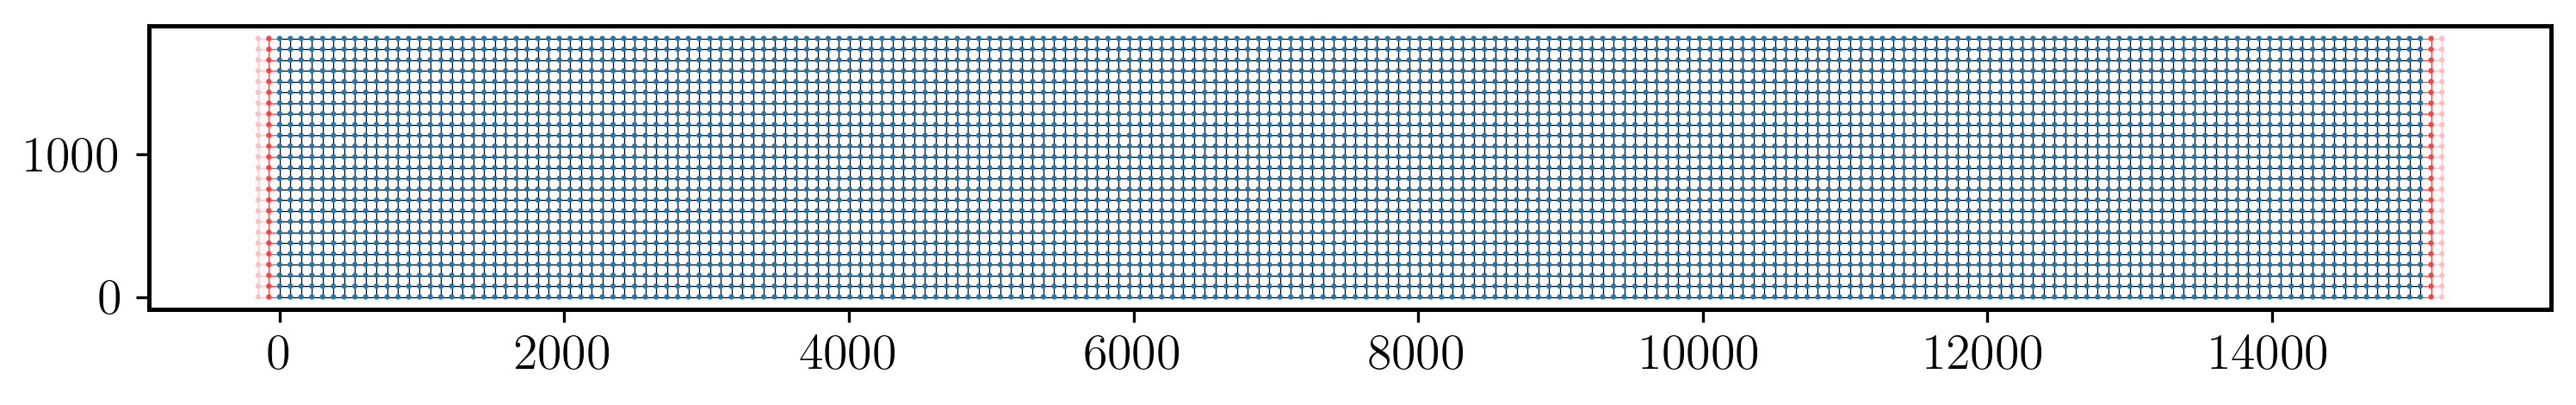

In [46]:
sys_vis = build_system(params)
kwant.plot(sys_vis, num_lead_cells=2, fig_size=(12, 4), show=False);

#### 1. Relacje dyspersji w kontakcie $E(k)$ zakładając, że oddziaływanie SO występuje w całym urządzeniu (wraz z kontaktami)

In [48]:
params.soc_region = False
params.alpha = 0.05 * eV_to_au(1.0) * nm_to_au(1.0)
 
k_max = 0.2
E_max = 0.03
nk = 201
 
momenta, energies = compute_dispersion(params, k_max=k_max, nk=nk)

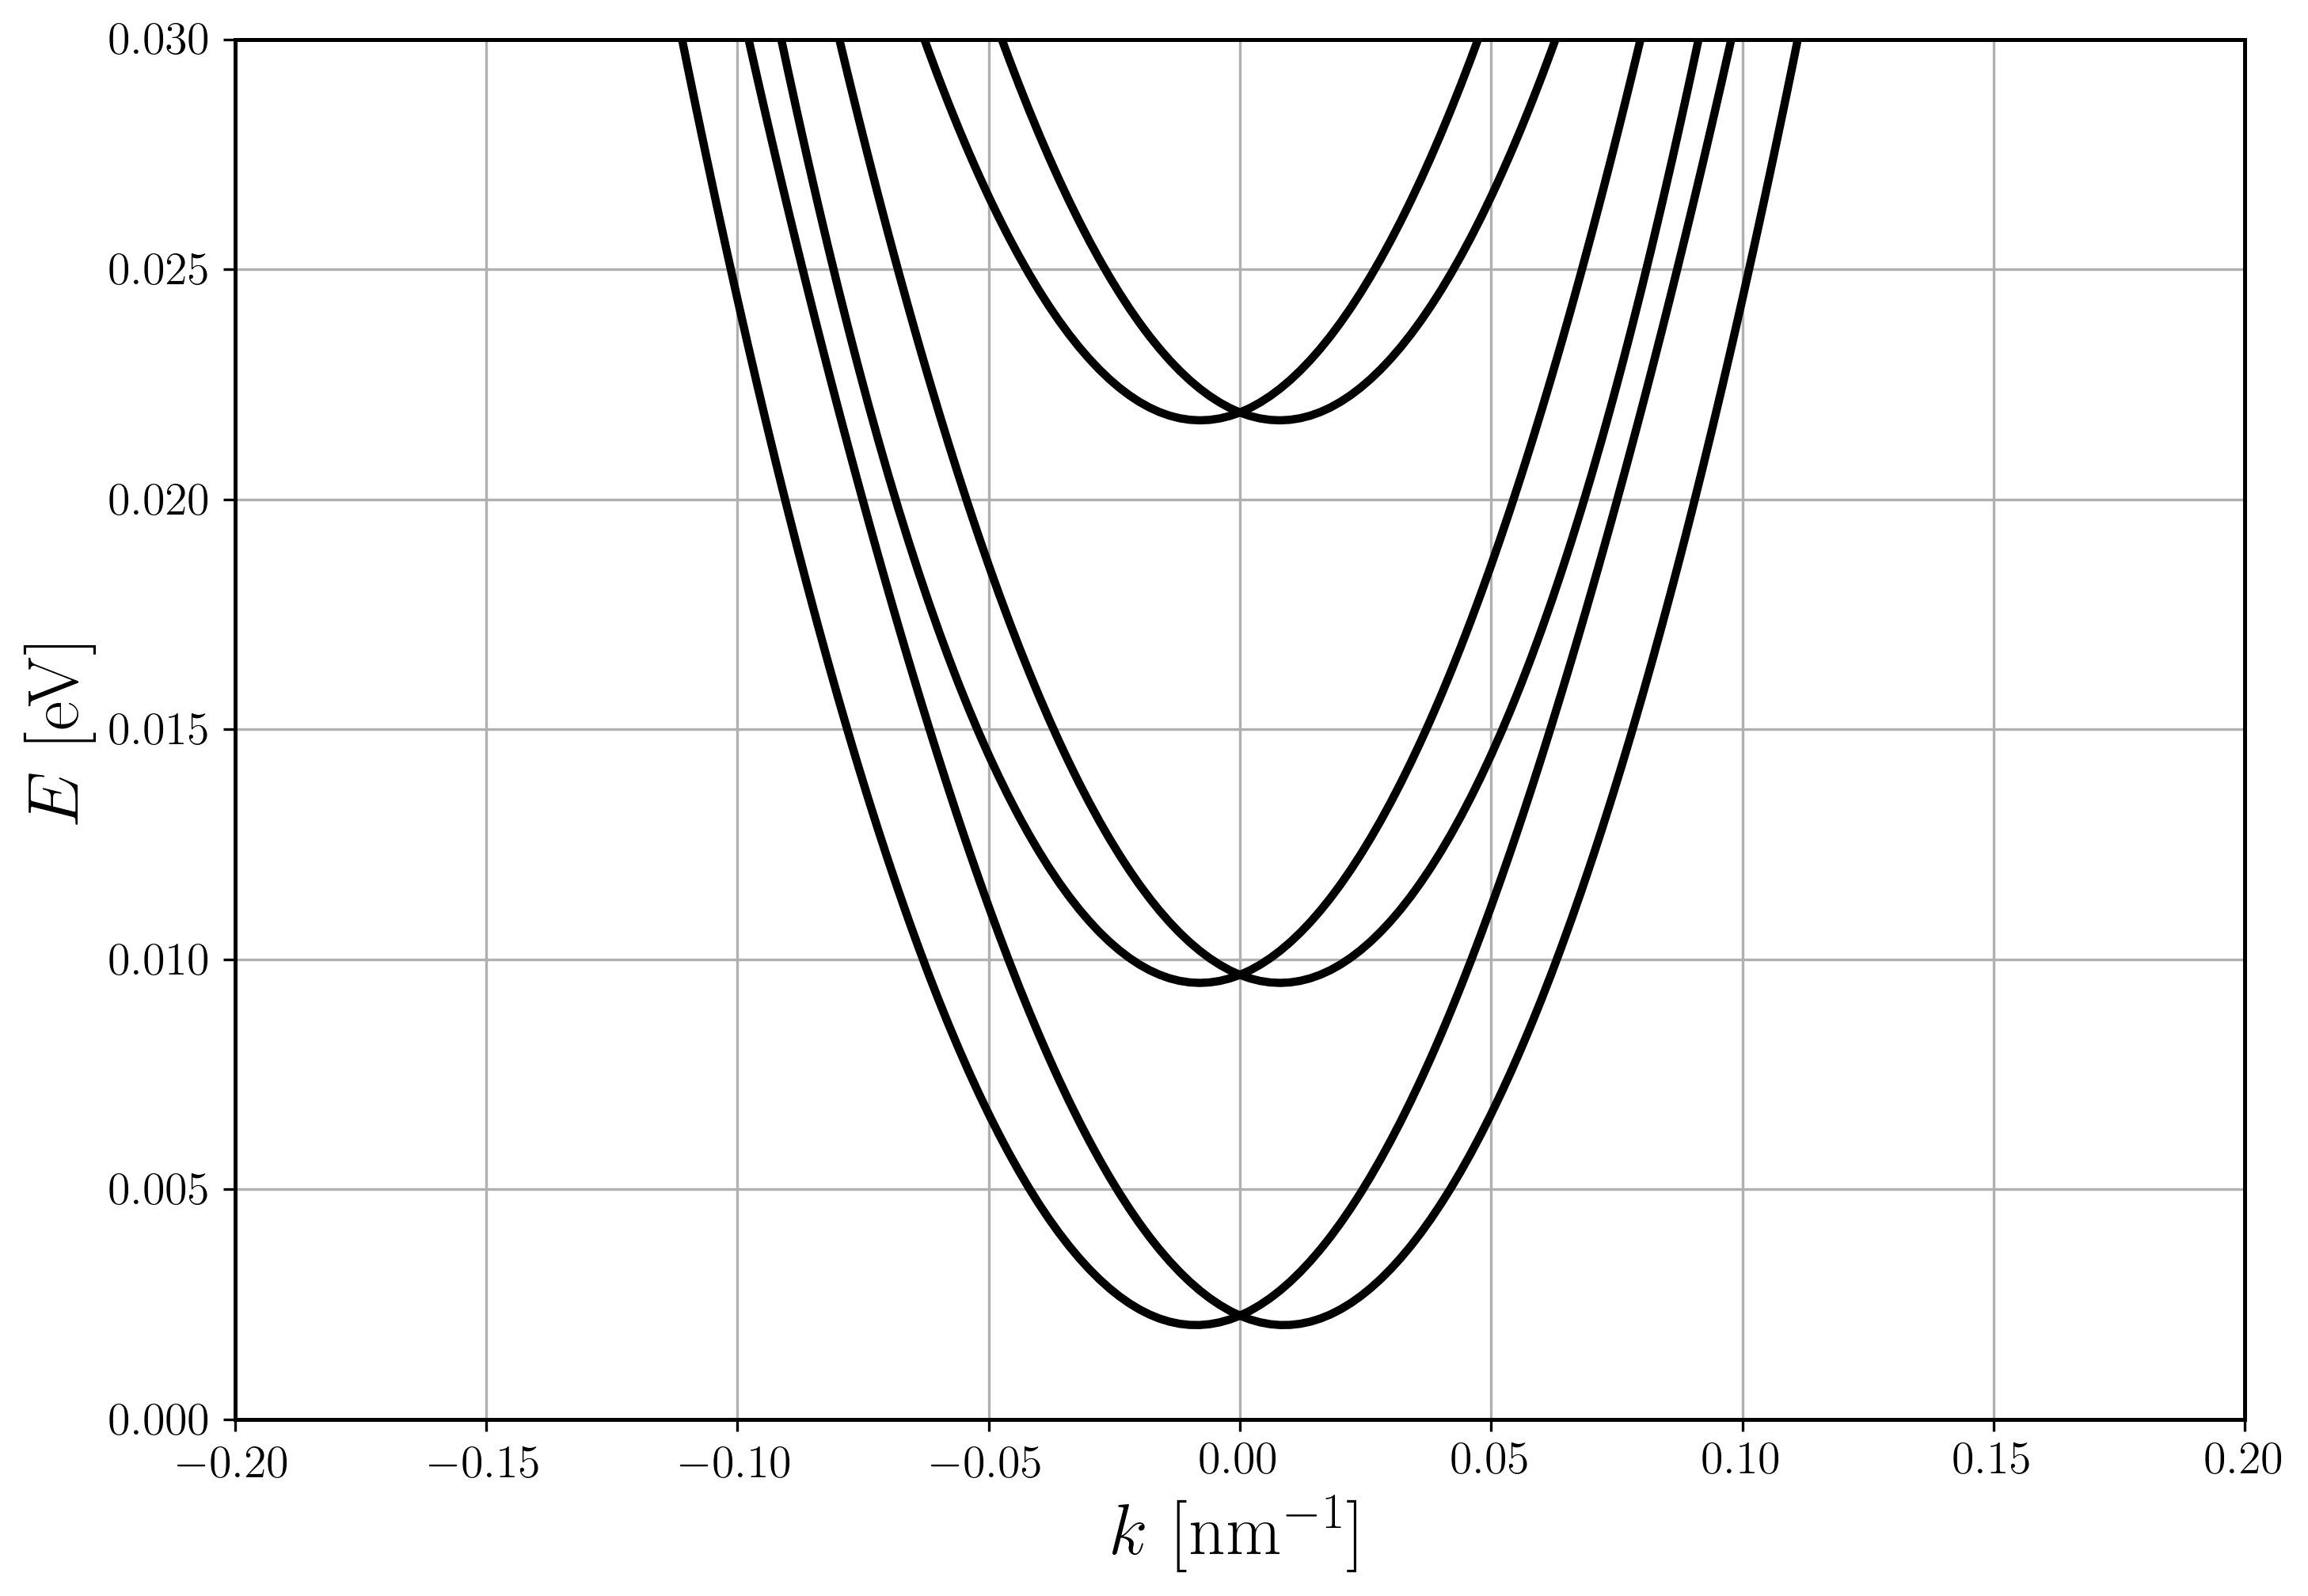

In [49]:
plt.figure()
plt.plot(momenta, np.array(energies) / eV_to_au(1.0), "k-")
plt.xlim(-k_max, k_max)
plt.ylim(0, E_max)
plt.xlabel(r"$k\ [\mathrm{nm}^{-1}]$")
plt.ylabel(r"$E\ [\mathrm{eV}]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_3/dispersion_SOC.png", dpi=150)
plt.show()

#### 2. Konduktancje w funkcji energii padającego elektronu zakładając, że oddziaływanie SO występuje w całym urządzeniu (wraz z kontaktami),

In [51]:
params.soc_region = False
 
energies_eV, cond = compute_conductance(params, E_max_eV=0.05, n_points=501)

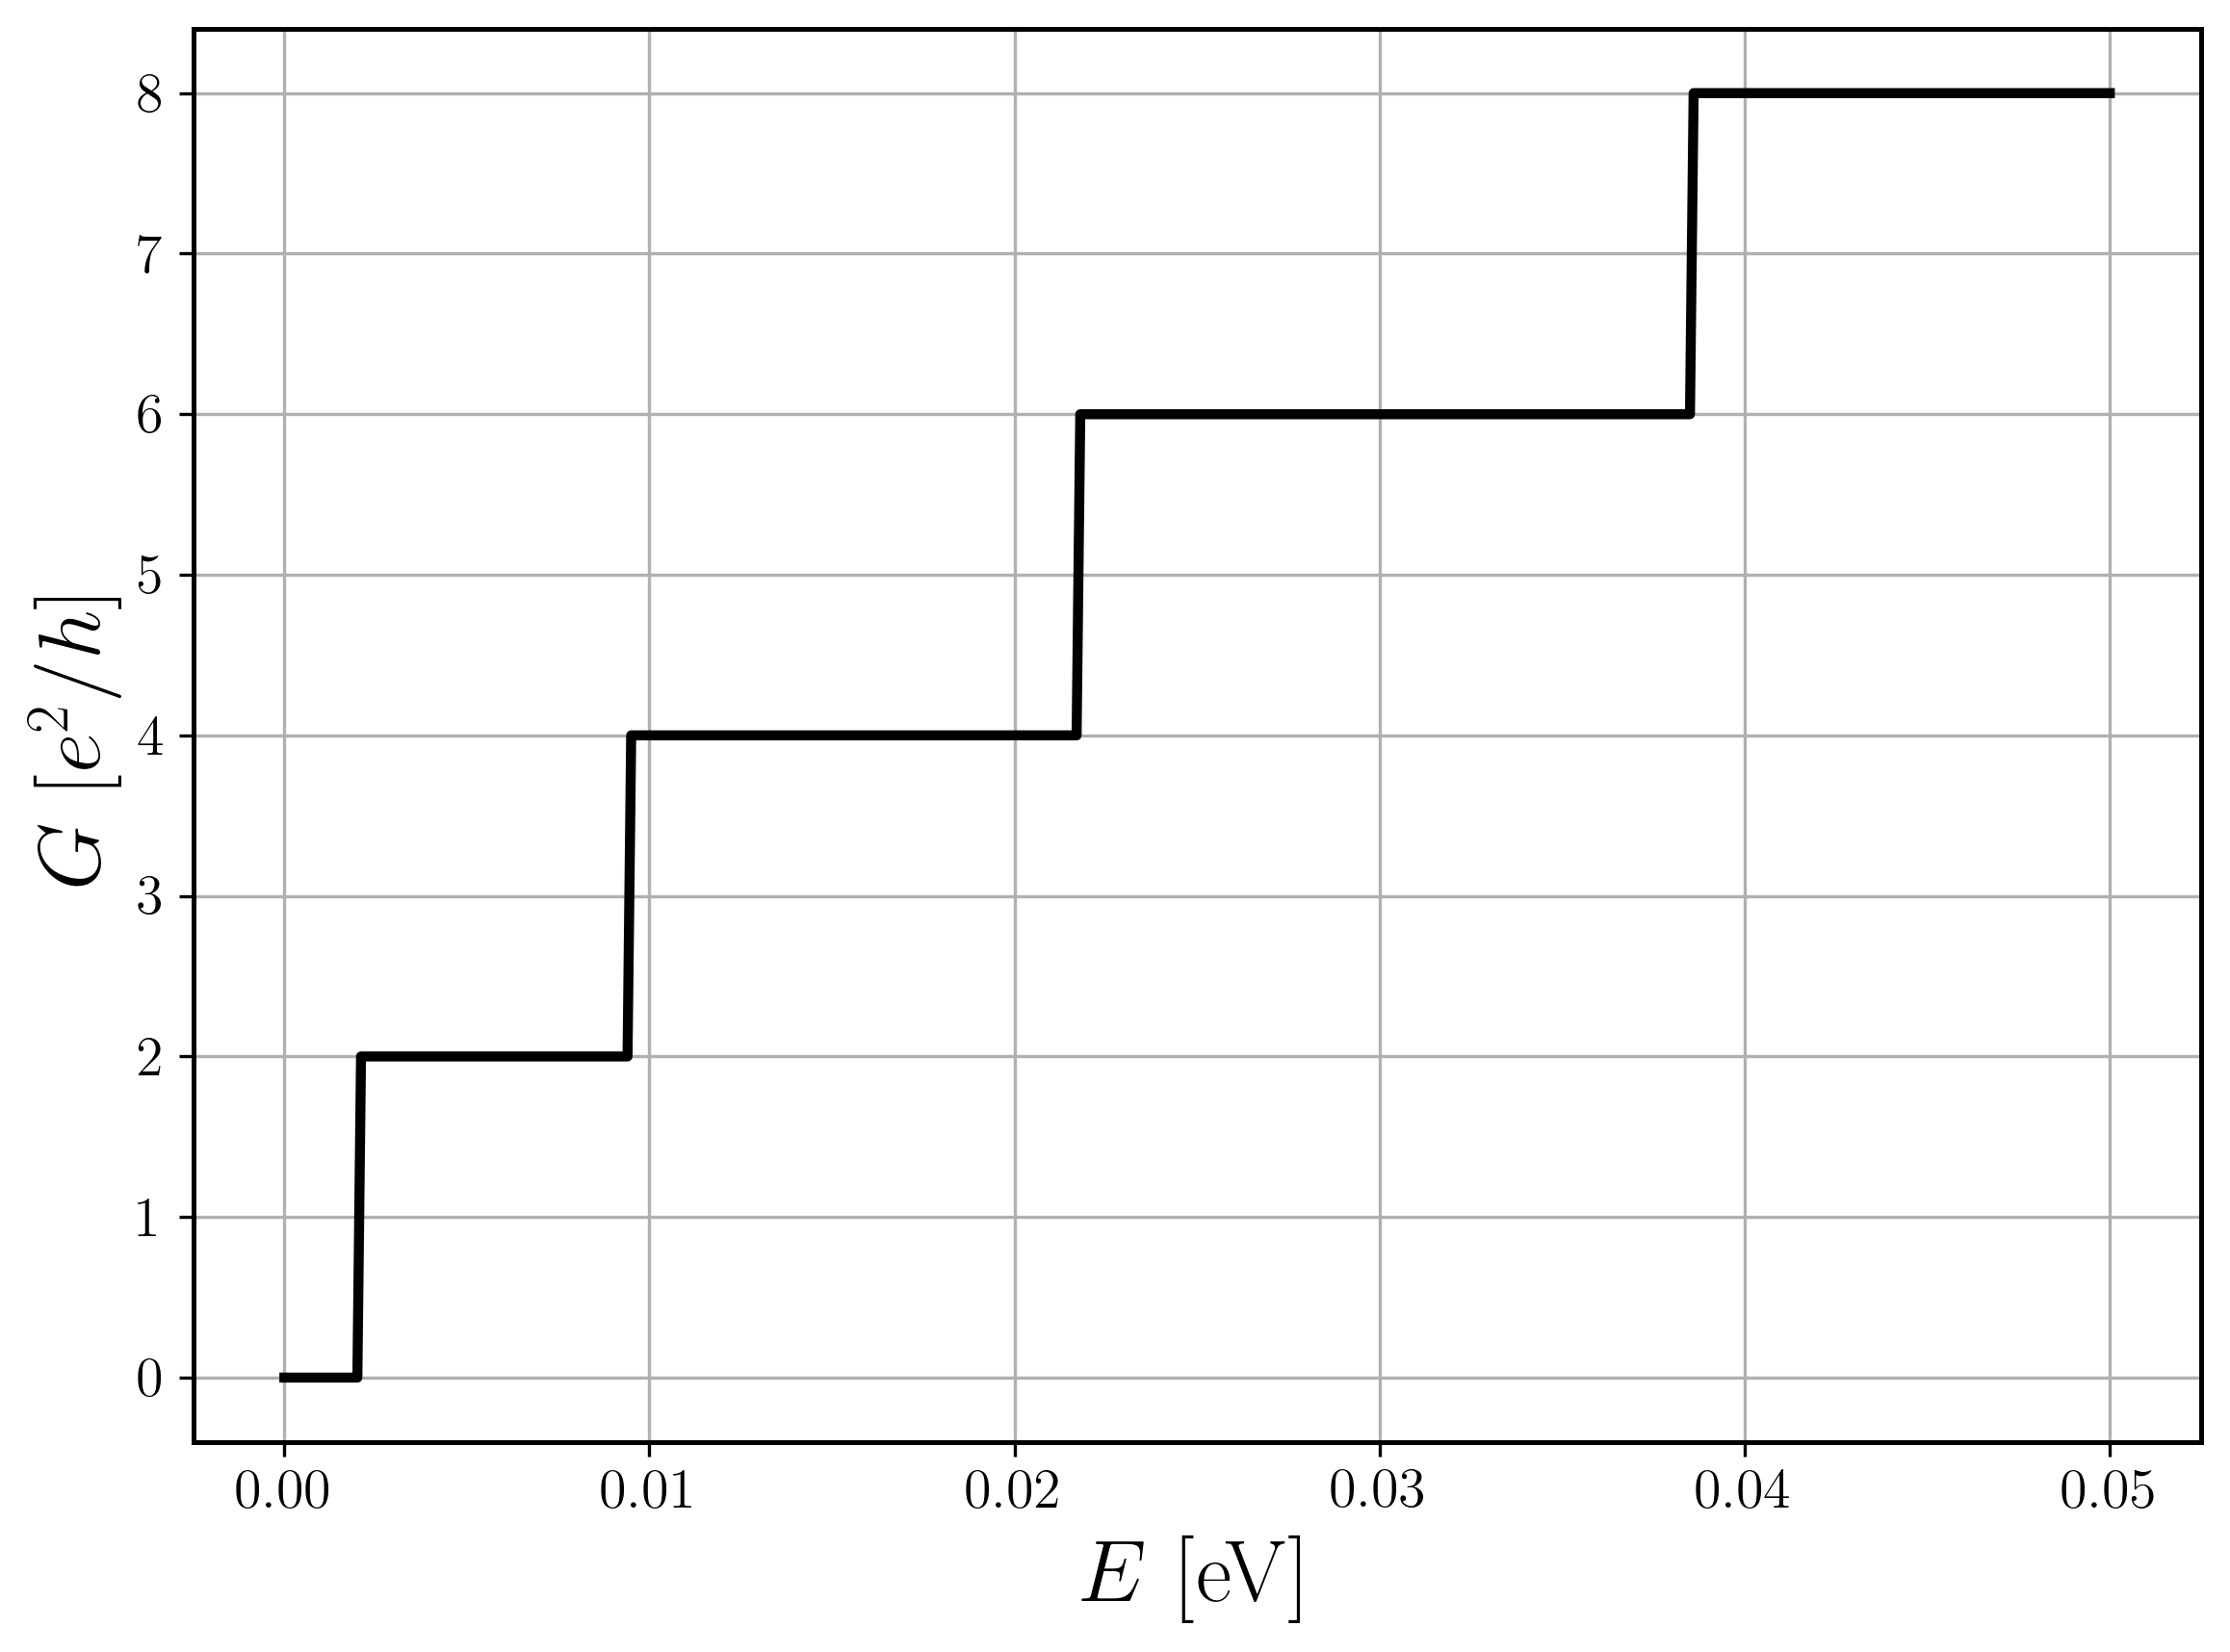

In [52]:
plt.figure(figsize=(8, 6))
plt.plot(energies_eV, cond, "k-")
plt.xlabel(r"$E\ [\mathrm{eV}]$")
plt.ylabel(r"$G\ [e^2/h]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_3/cond_SOC.png", dpi=150)
plt.show()

#### 3. współczynniki transmisji $T_{up←up} , T_{down←up} , T_{up←down}$ oraz $T_{down←down}$ w funkcji parametru $α$ zakładając, że oddziaływanie SO występuje w obszarze $[0.2, 0.8] L$ oraz że elektron jest wstrzyknięty w najniższym pasmie poprzecznym ($E = 5$ [ meV ]), parametr $α$ zmieniać w zakresie $[0, 50]$ [ meVnm ]

In [ ]:
params.soc_region = True
 
n = 201
E = eV_to_au(0.005)
alpha_range = np.linspace(0.0, 0.05, n)
 
Tuu = np.zeros(n)
Tud = np.zeros(n)
Tdu = np.zeros(n)
Tdd = np.zeros(n)
 
for i, a in enumerate(alpha_range):
    params.alpha = a * eV_to_au(1.0) * nm_to_au(1.0)
    sys = build_system(params)
    sm = kwant.smatrix(sys, E)
    Tuu[i] = sm.transmission((1, 0), (0, 0))
    Tud[i] = sm.transmission((1, 1), (0, 0))
    Tdu[i] = sm.transmission((1, 0), (0, 1))
    Tdd[i] = sm.transmission((1, 1), (0, 1))

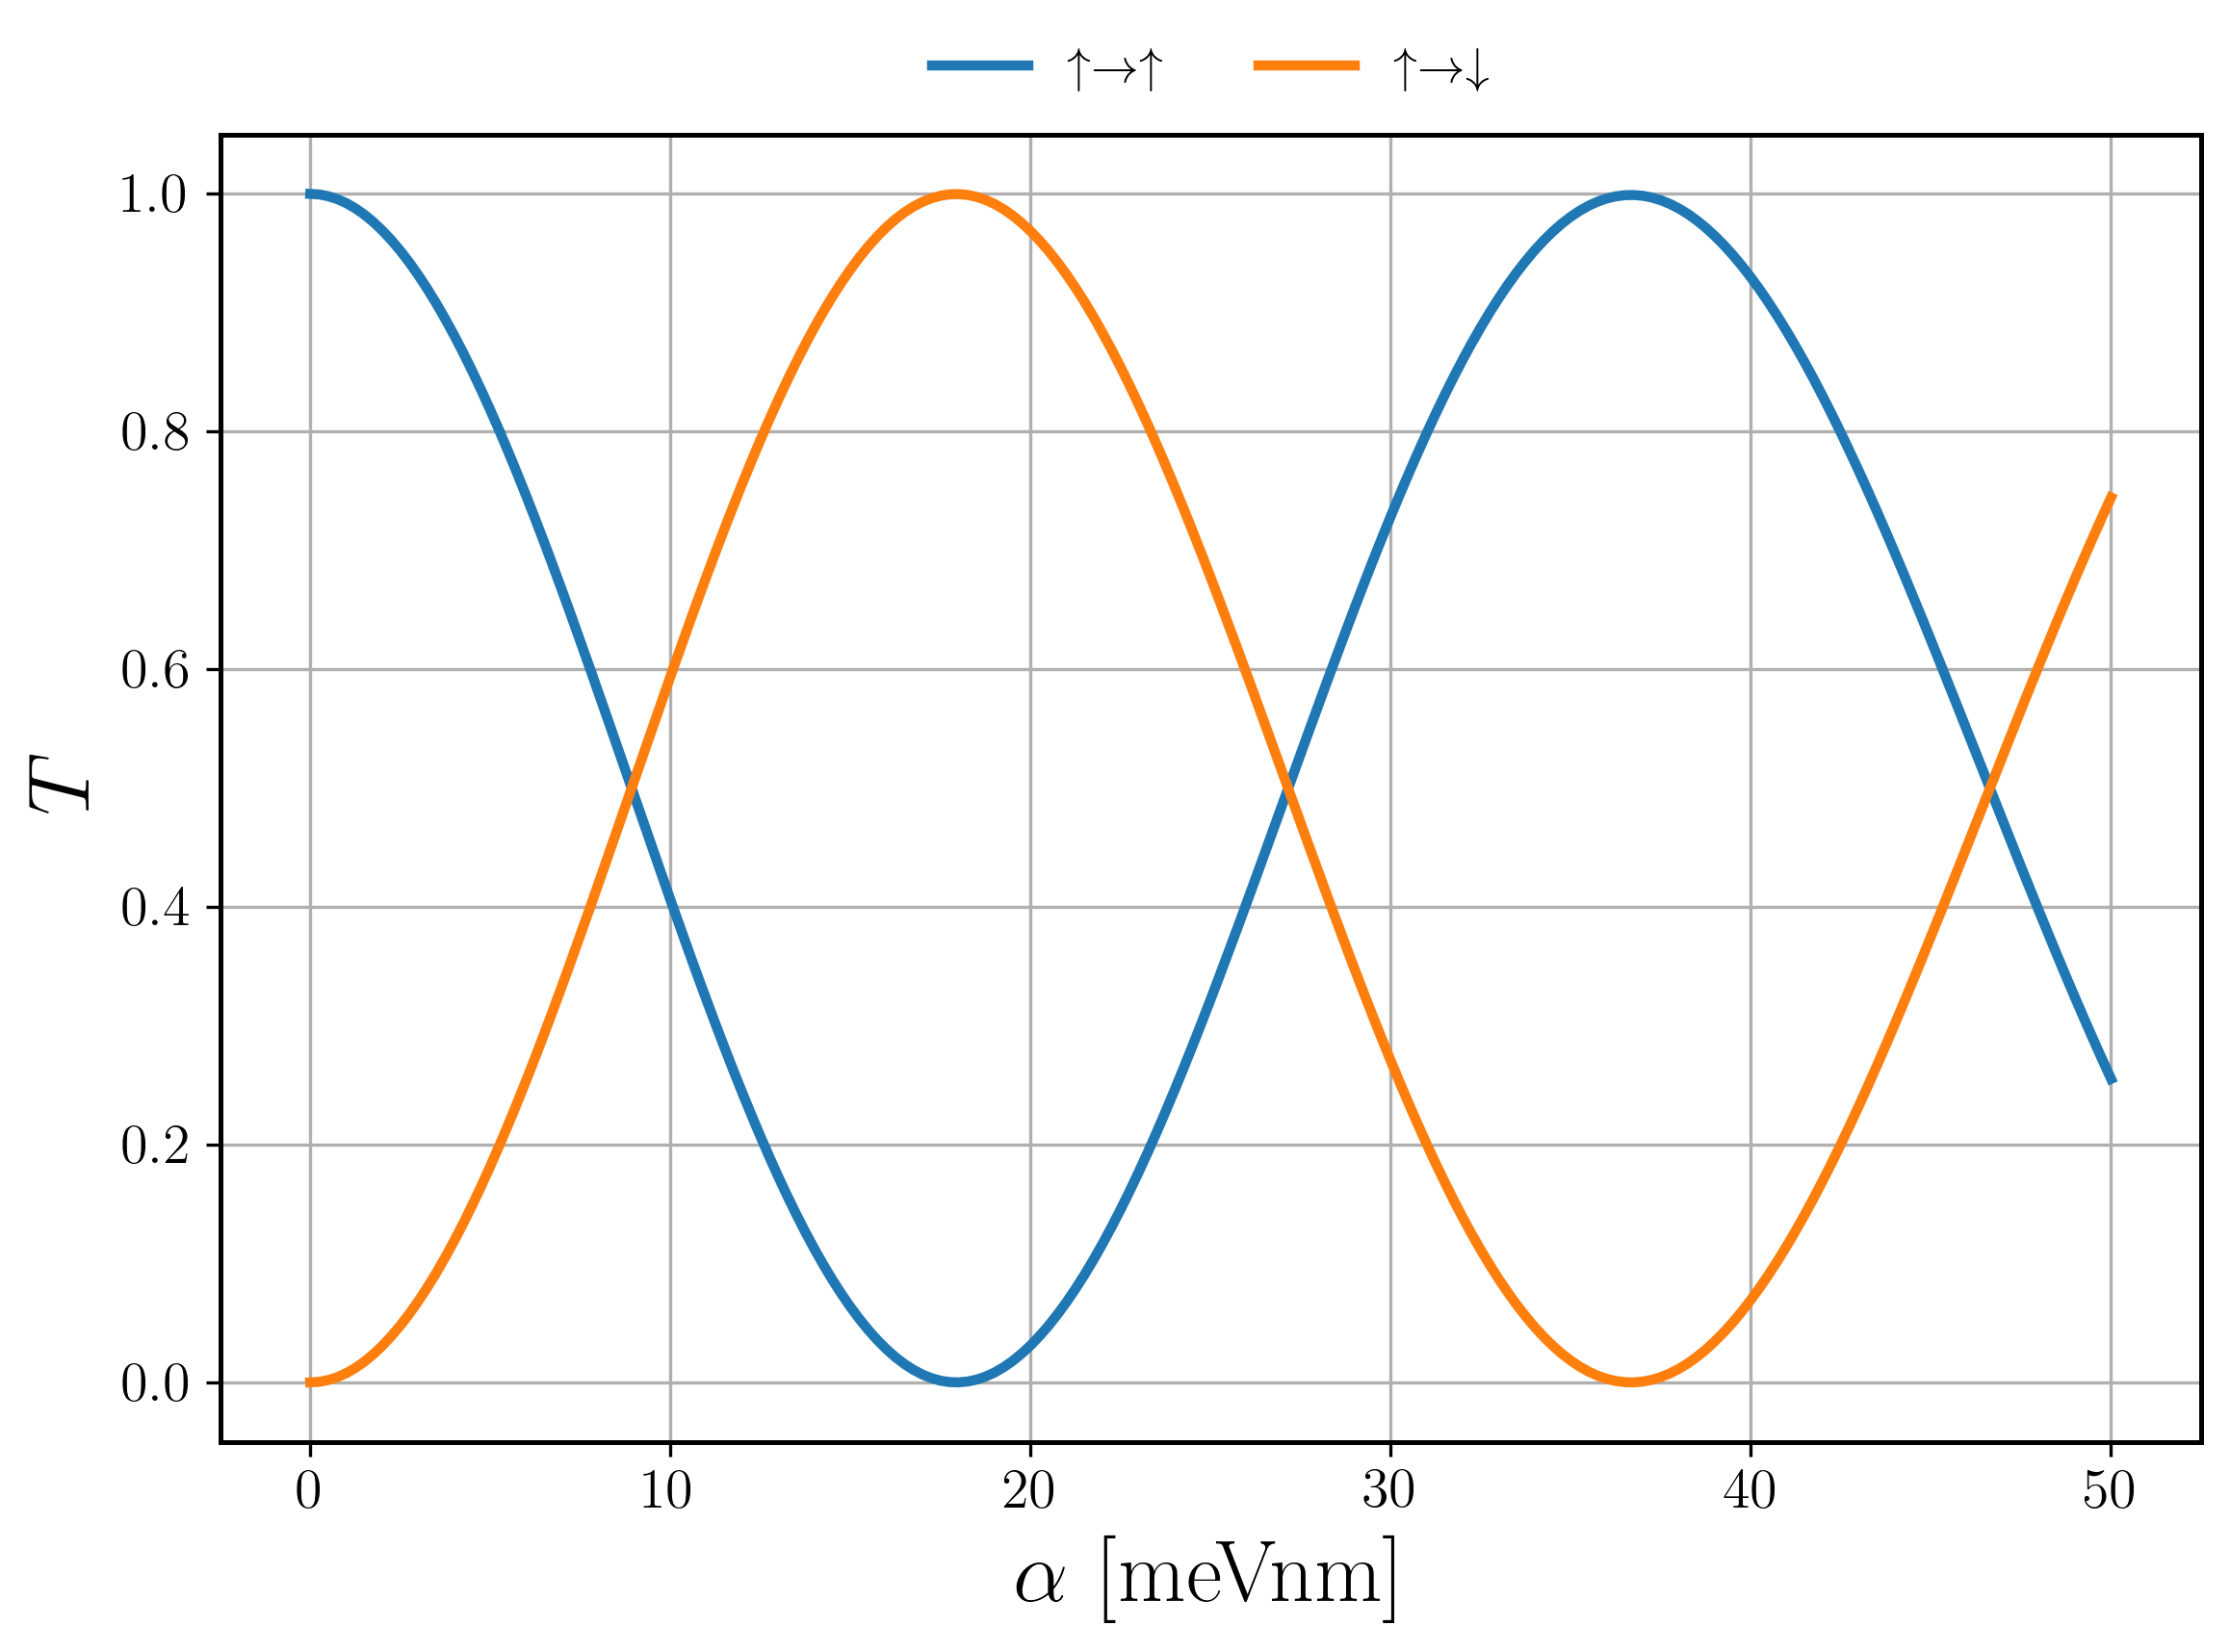

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(alpha_range * 1e3, Tuu, label=r"$\uparrow \rightarrow \uparrow$")
plt.plot(alpha_range * 1e3, Tud, label=r"$\uparrow \rightarrow \downarrow$")
plt.xlabel(r"$\alpha\ [\mathrm{meVnm}]$")
plt.ylabel(r"$T$")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2)
plt.grid()
plt.tight_layout()
plt.savefig("zad_3/Tu_SOC.png", dpi=150)
plt.show()

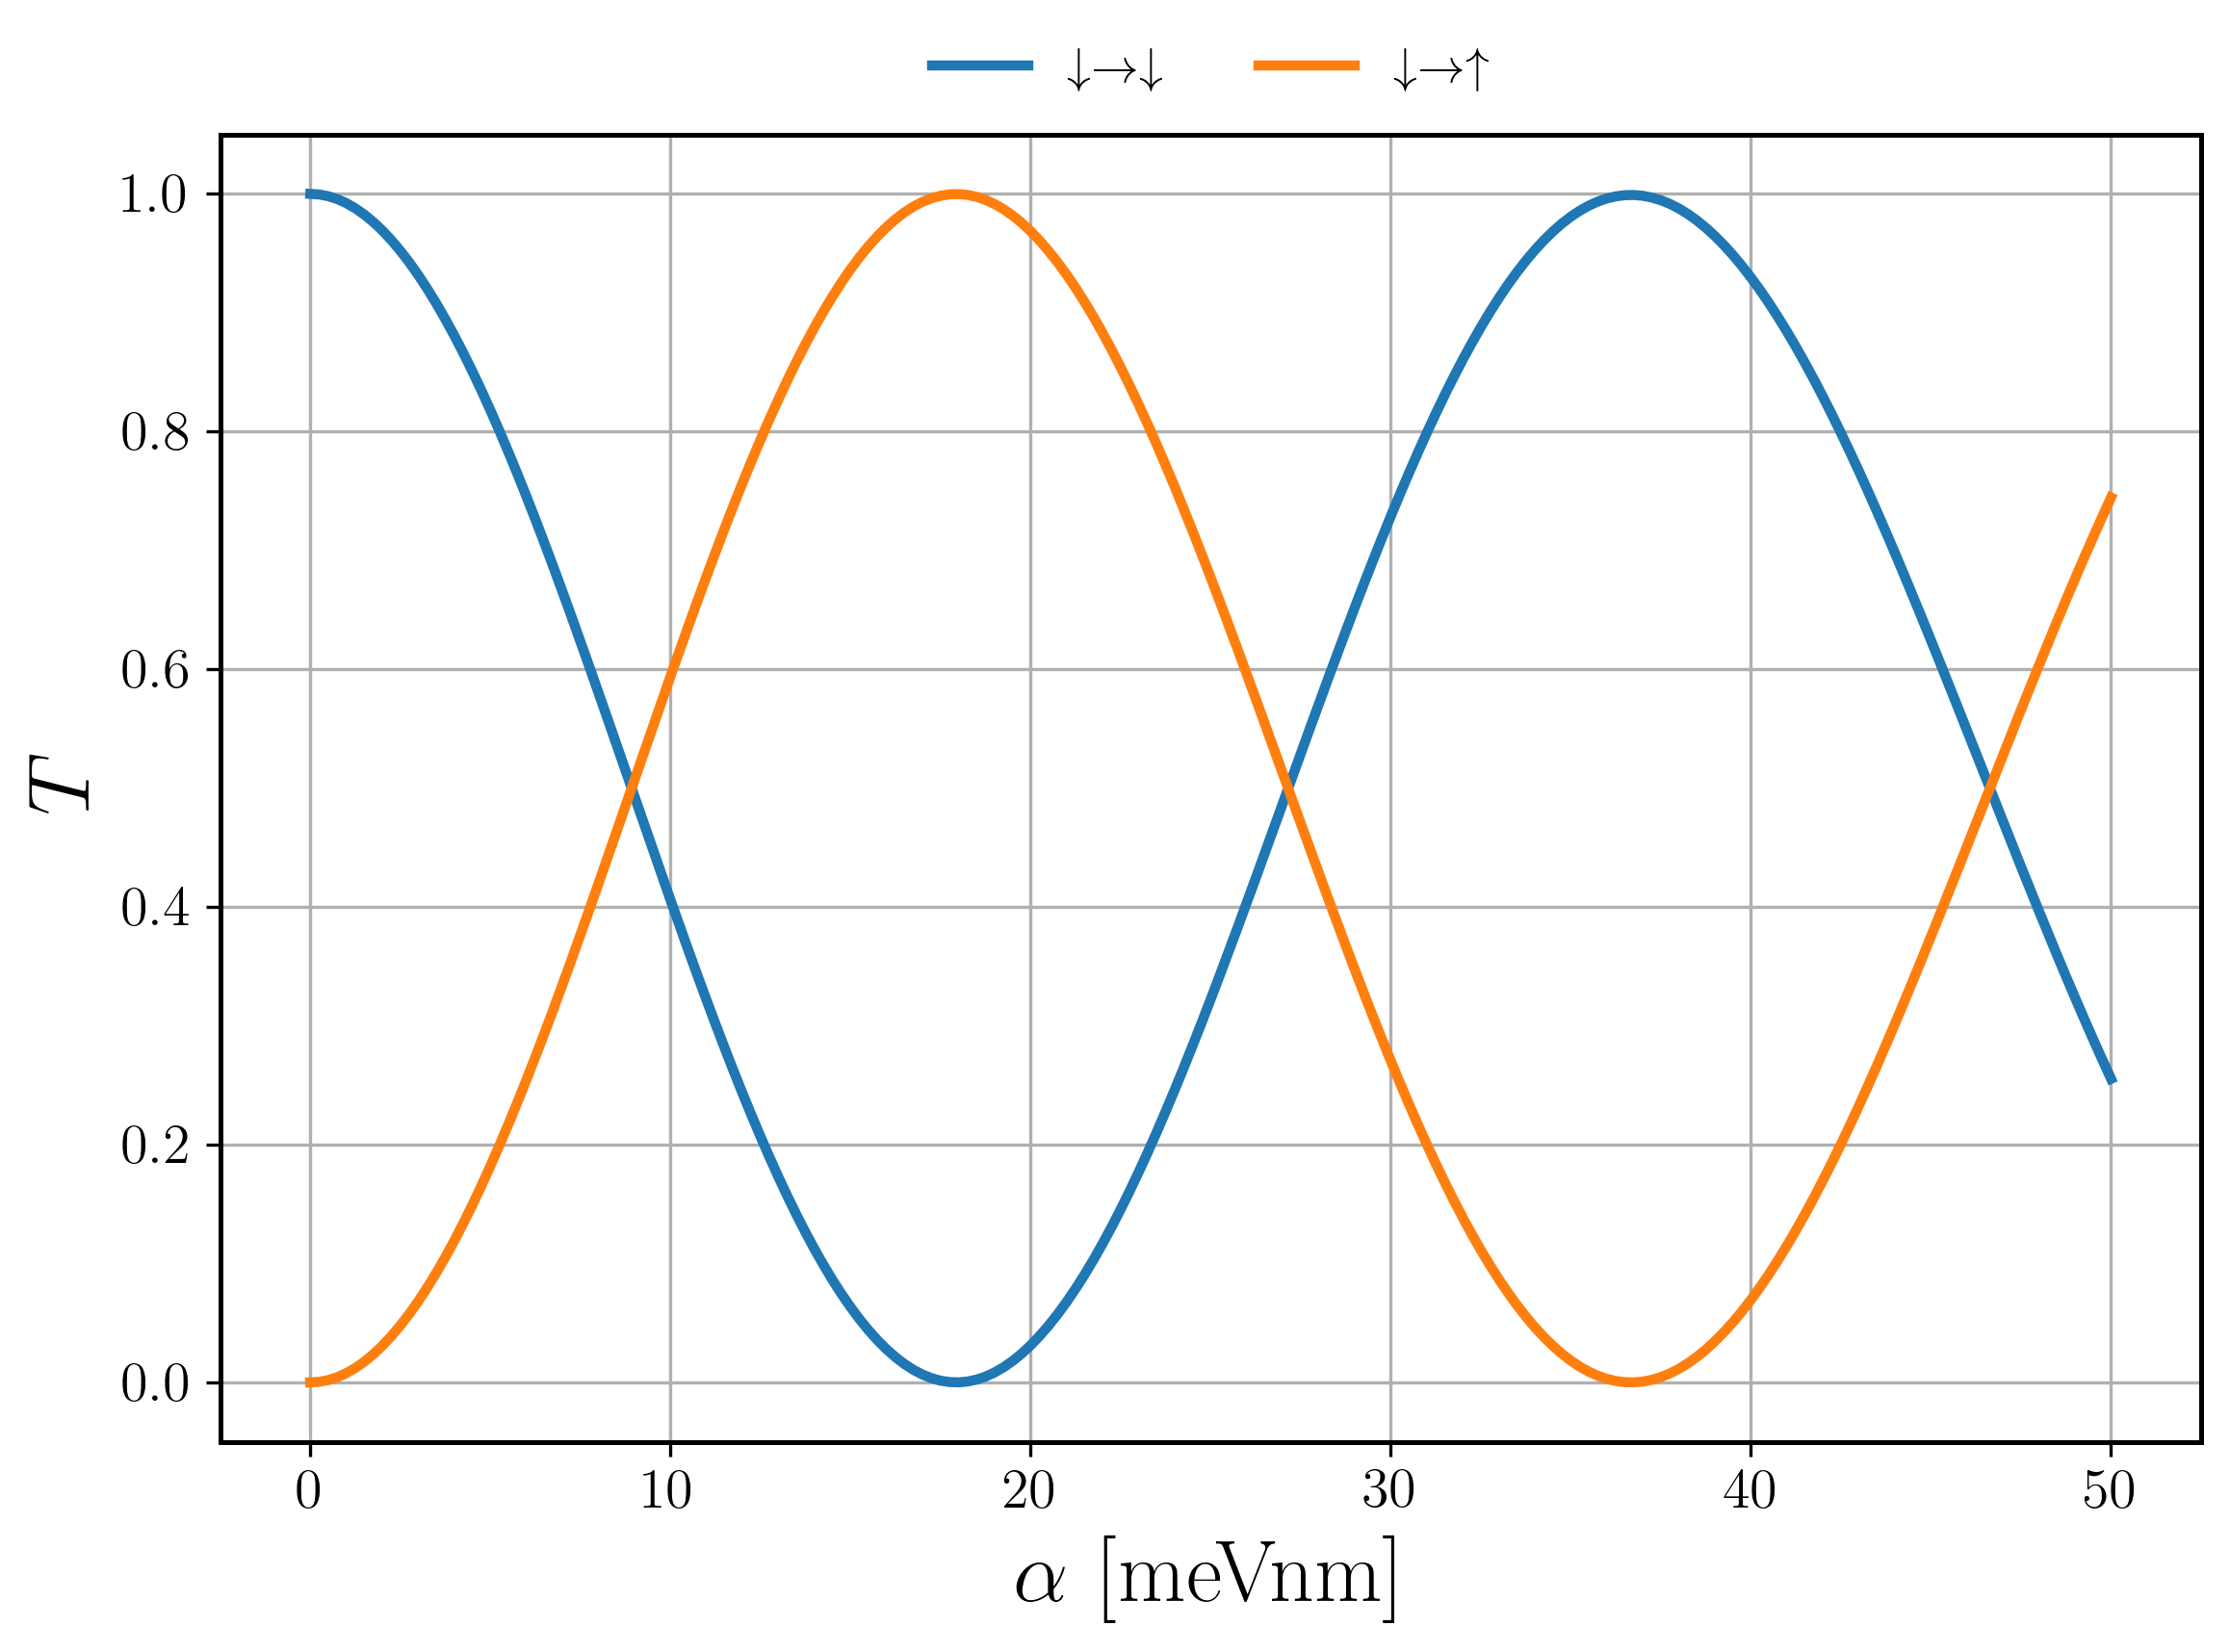

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(alpha_range * 1e3, Tdd, label=r"$\downarrow \rightarrow \downarrow$")
plt.plot(alpha_range * 1e3, Tdu, label=r"$\downarrow \rightarrow \uparrow$")
plt.xlabel(r"$\alpha\ [\mathrm{meVnm}]$")
plt.ylabel(r"$T$")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2)
plt.grid()
plt.tight_layout()
plt.savefig("zad_3/Td_SOC.png", dpi=150)
plt.show()

#### 4. dla układu z punktu 3, konduktancje $G$, $G_{up}$ oraz $G_{down}$ w funkcji parametru $\alpha$ dla elektronu wstrzykniętego w najniższym pasmie poprzecznym, przyjmując kolejno $P = 0.2, 0.4, 1$

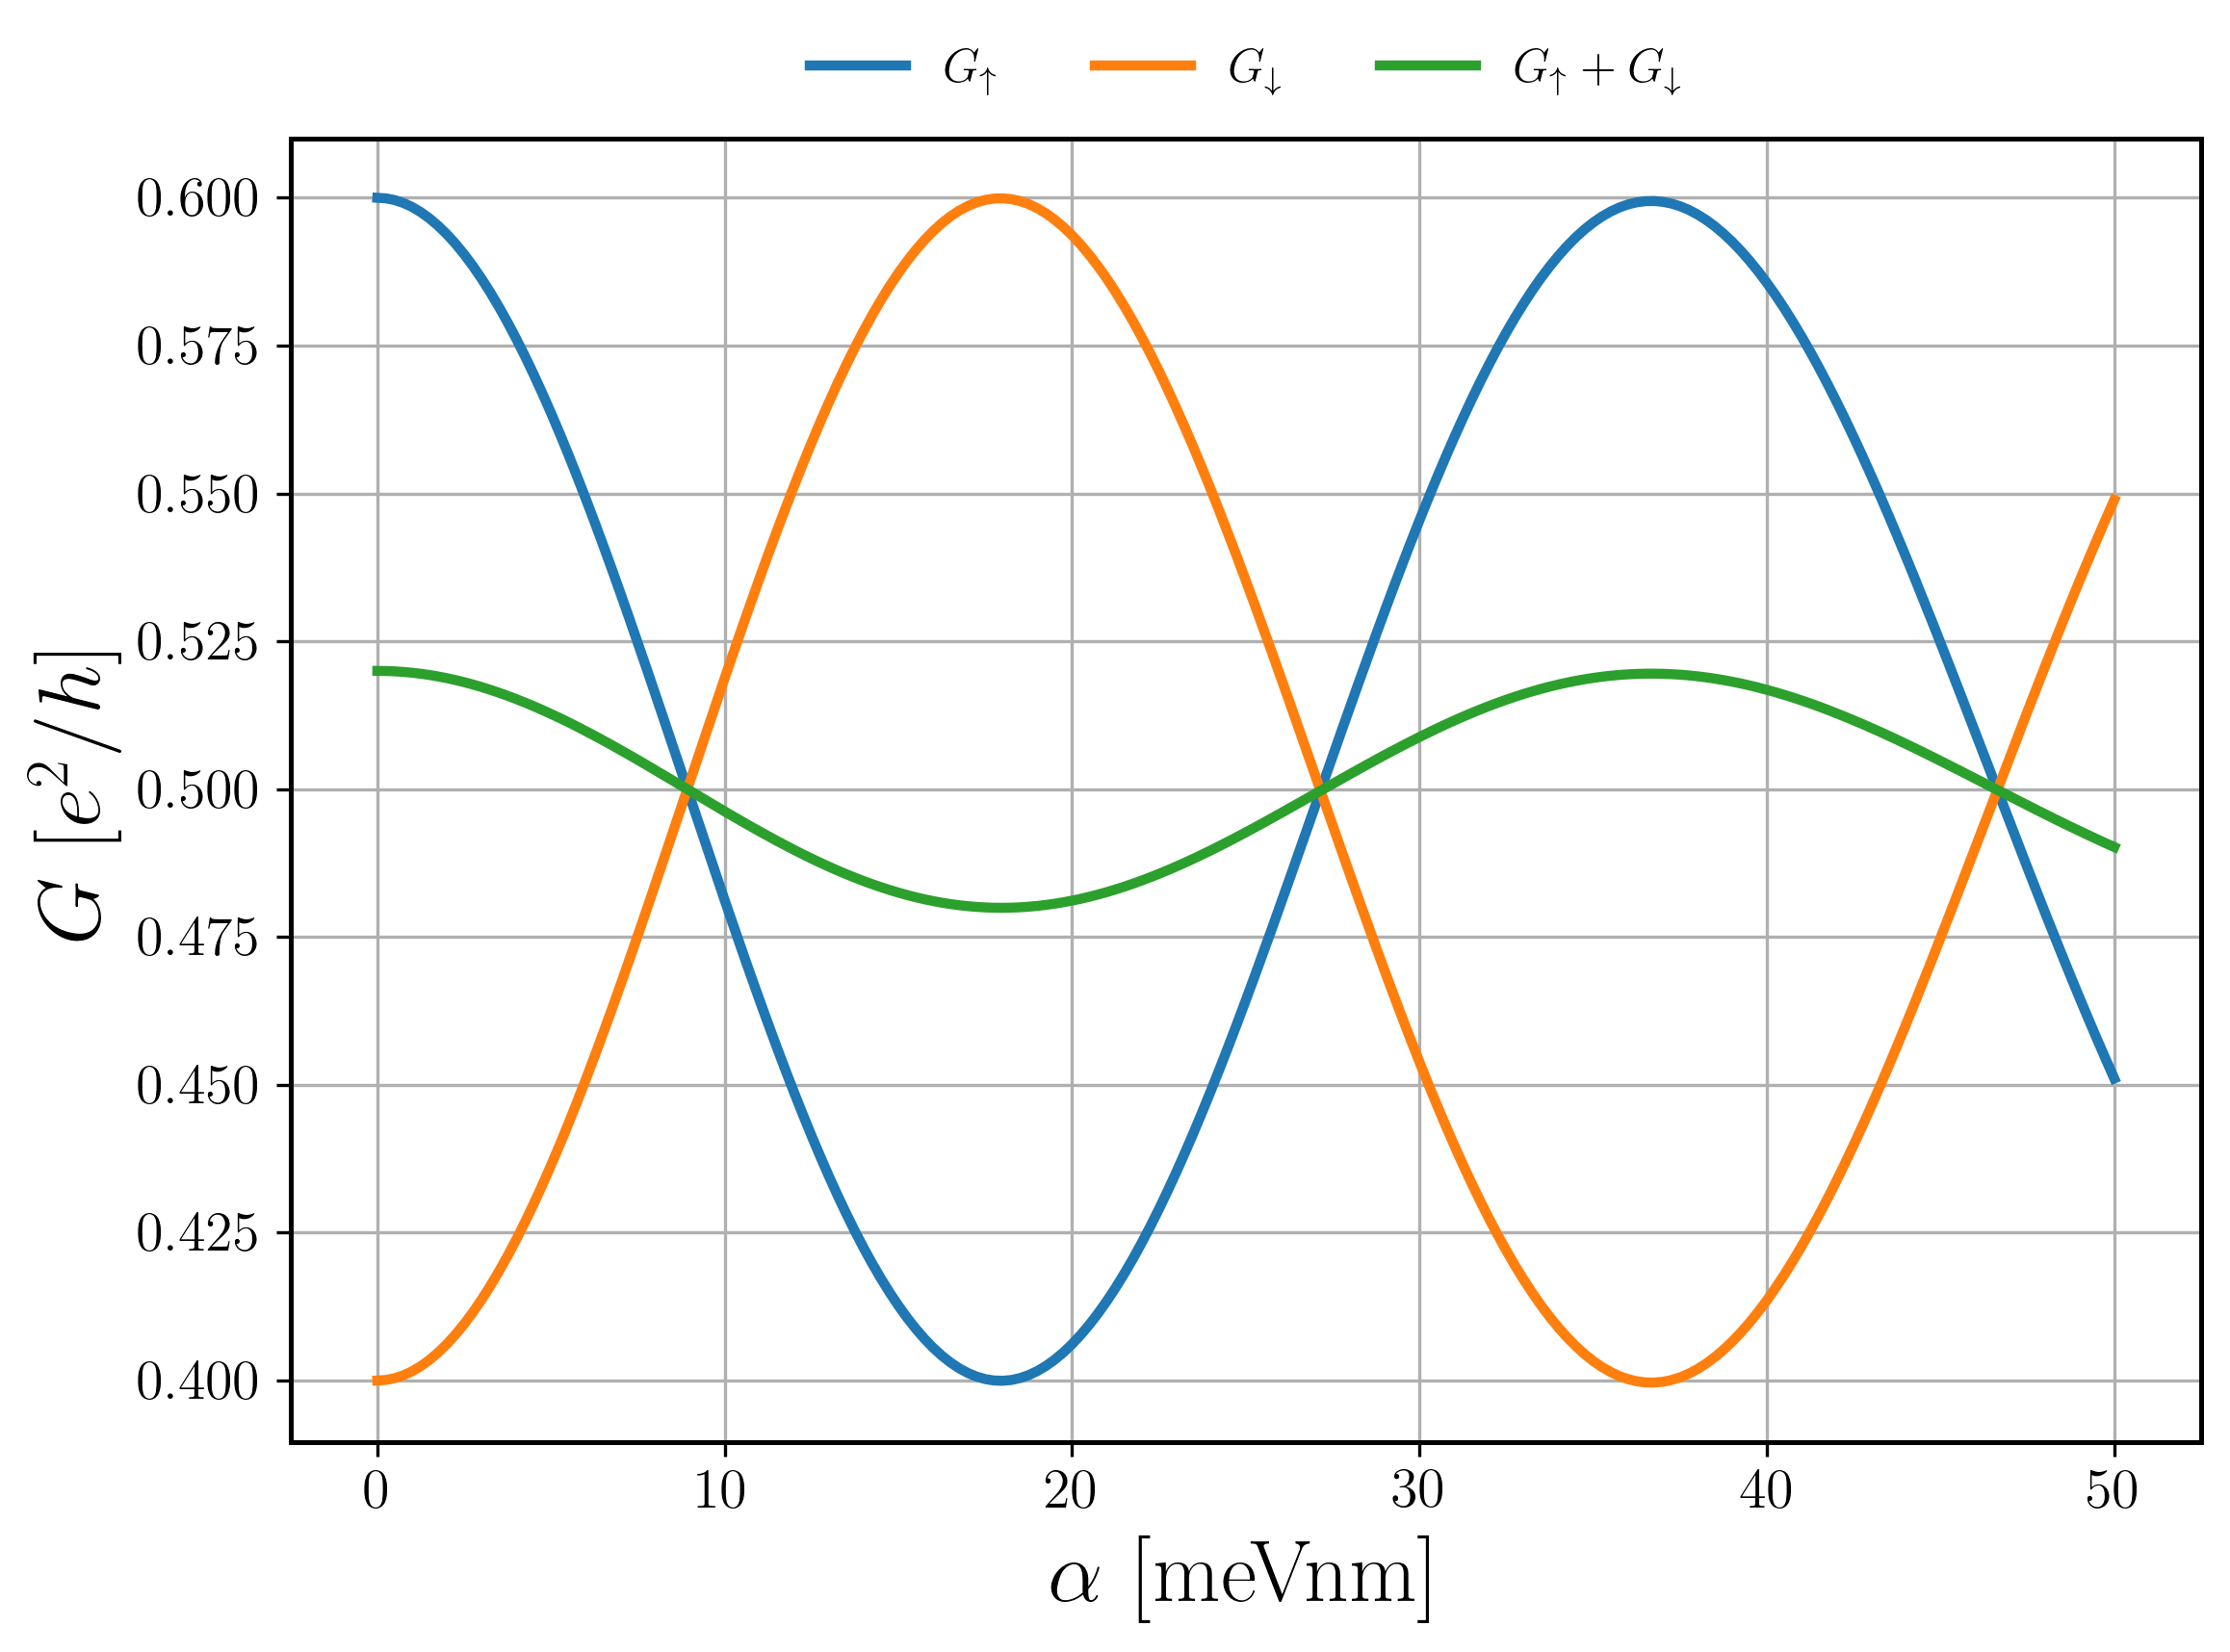

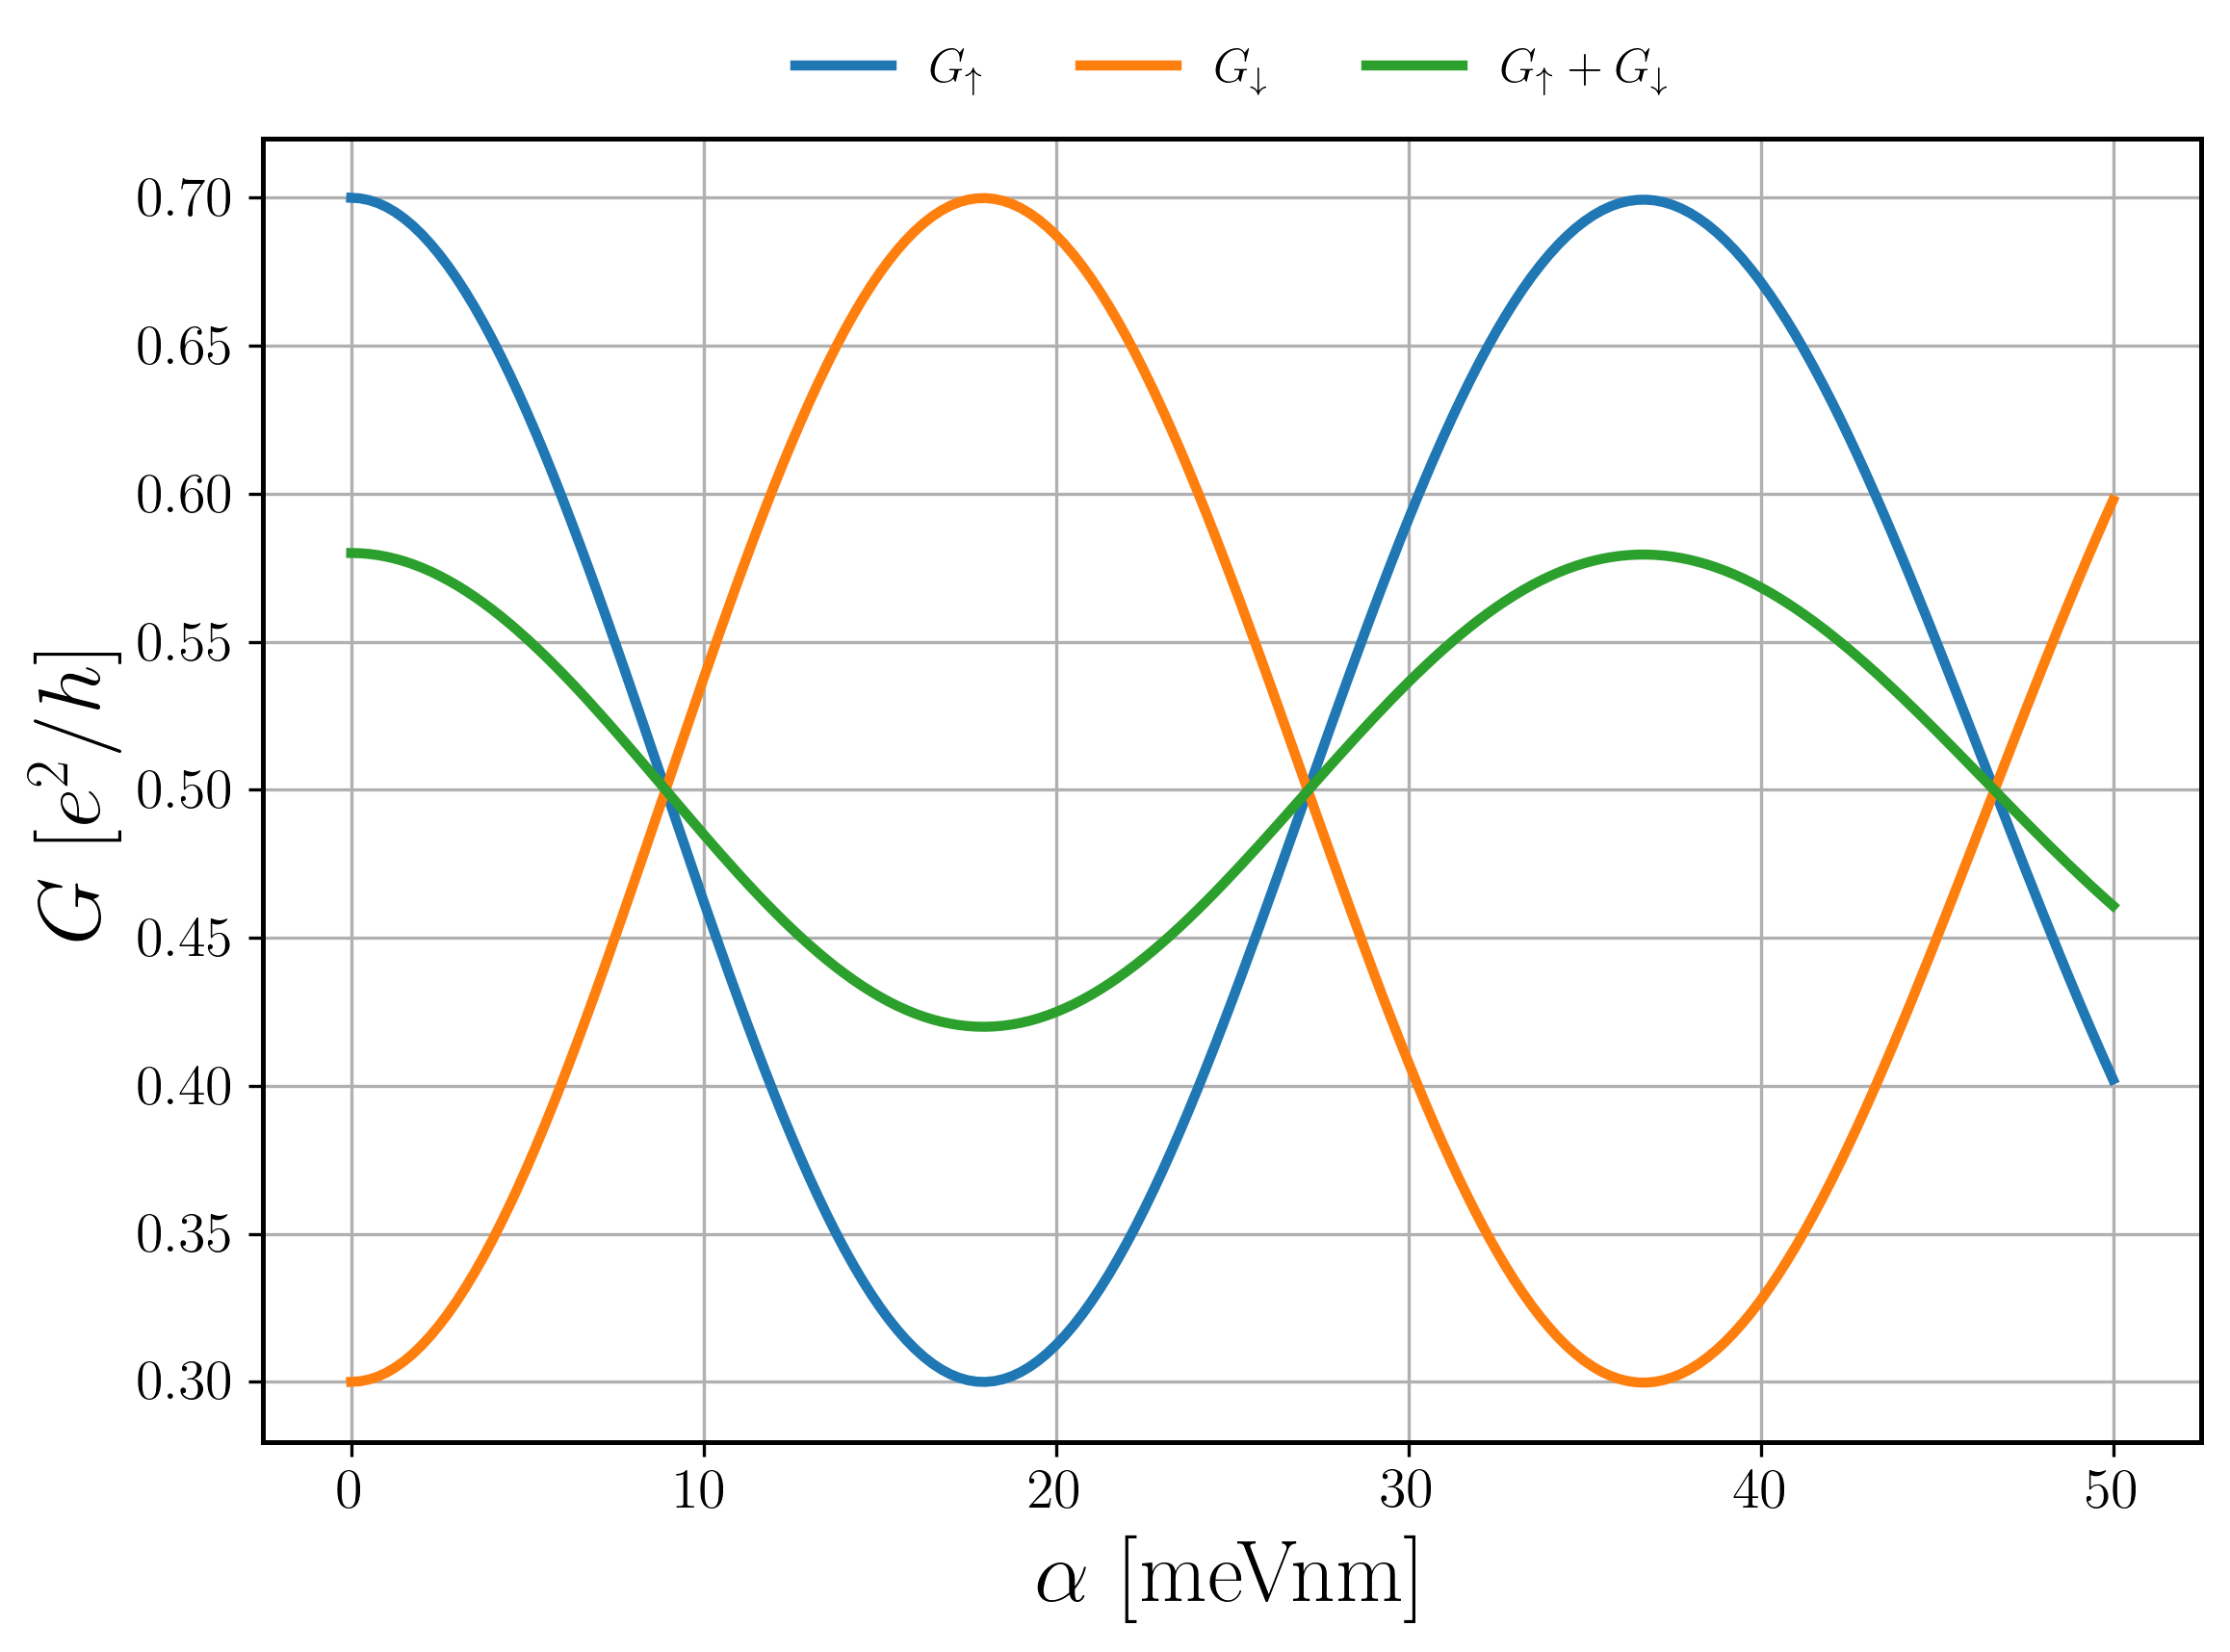

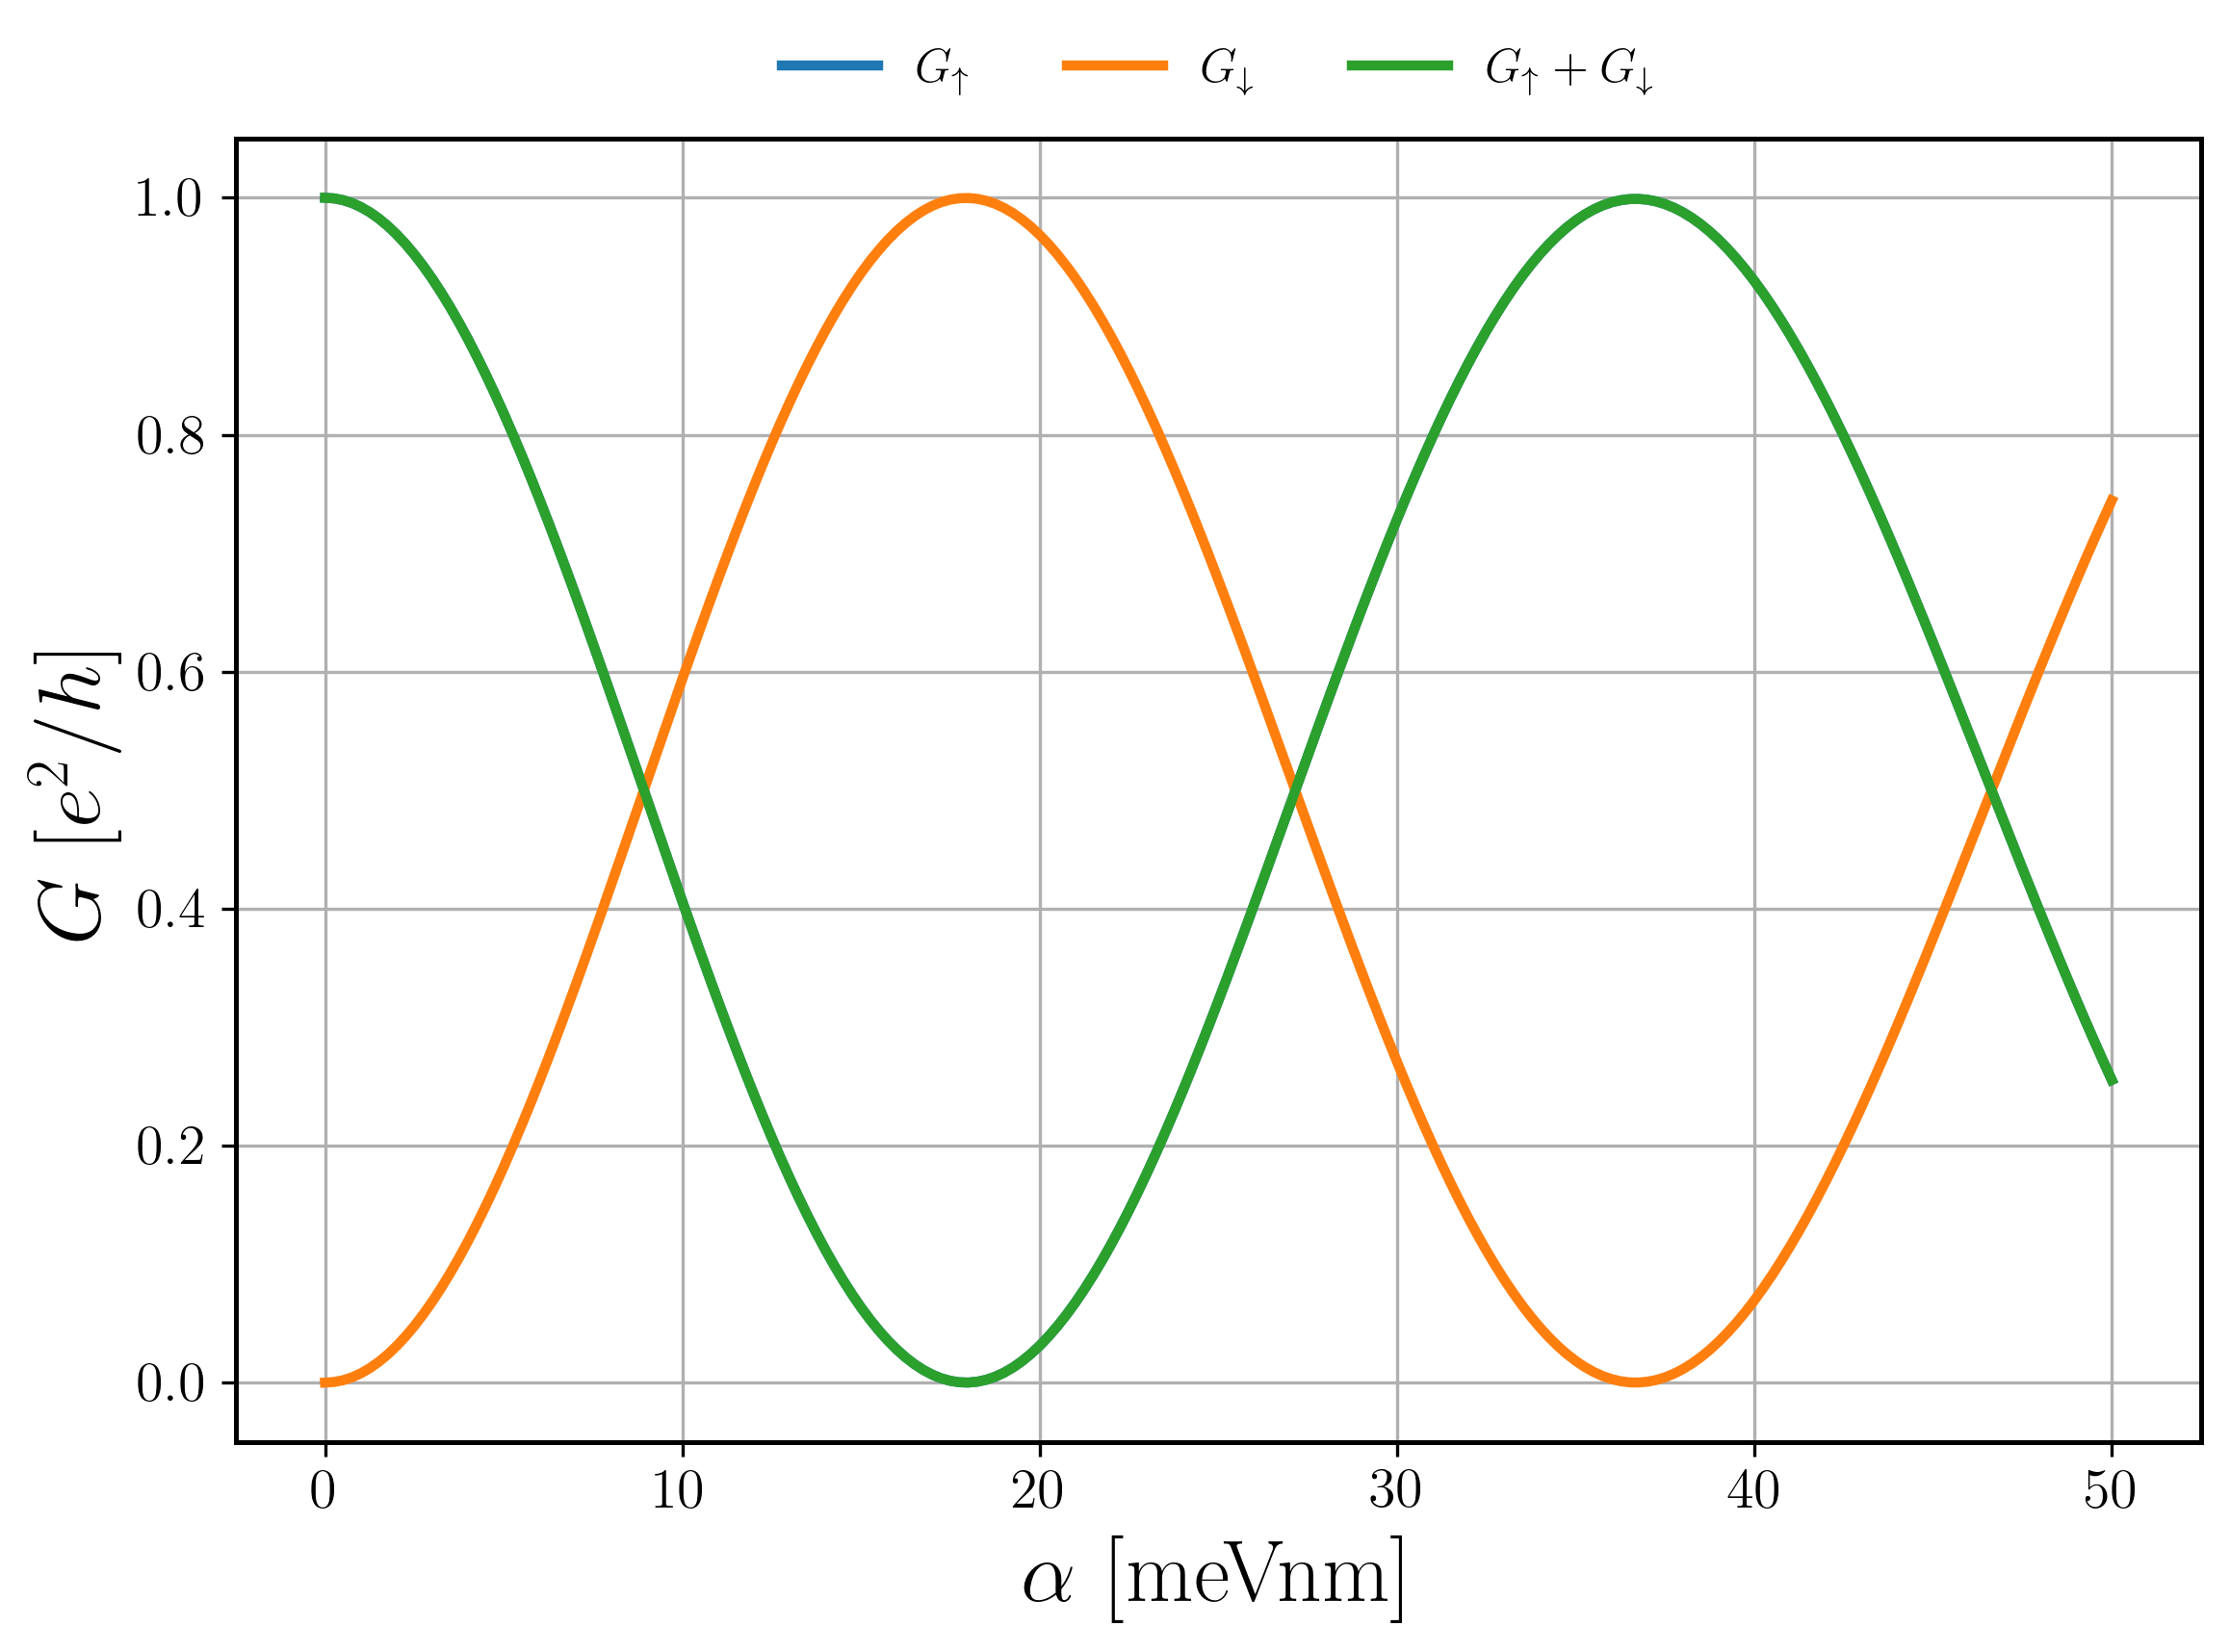

In [26]:
for iP, P in enumerate([0.2, 0.4, 1.0]):
    Gu = (1 + P) / 2 * Tuu + (1 - P) / 2 * Tdu
    Gd = (1 + P) / 2 * Tud + (1 - P) / 2 * Tdd
    Gt = (1 + P) / 2 * Gu  + (1 - P) / 2 * Gd
 
    plt.figure(figsize=(8, 6))
    plt.plot(alpha_range * 1e3, Gu, label=r"$G_{\uparrow}$")
    plt.plot(alpha_range * 1e3, Gd, label=r"$G_{\downarrow}$")
    plt.plot(alpha_range * 1e3, Gt, label=r"$G_{\uparrow}+G_{\downarrow}$")
    plt.xlabel(r"$\alpha\ [\mathrm{meVnm}]$")
    plt.ylabel(r"$G\ [e^2/h]$")
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3)
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"zad_3/G_SOC_{iP}.png", dpi=150)
    plt.show()

#### 5. dla układu z punktu 3, gęstość elektronów o spinie up i down oraz gęstość spinu $s_x, s_y , s_z$ w nanourządzeniu dla elektronu wstrzykniętego w najniższym pasmie poprzecznym oraz parametru $α$ odpowiadającemu całkowitemu obrotowi spinu.

In [ ]:
flip_alpha = alpha_range[np.argmax(Tud)]
print(f"Alpha calkowitego obrotu spinu: {flip_alpha * 1e3:.2f} meVnm")
 
params.alpha = flip_alpha * eV_to_au(1.0) * nm_to_au(1.0)
sys = build_system(params)
wf = kwant.wave_function(sys, E)(0)
 
rho_up_op = kwant.operator.Density(sys, ta.array([[1, 0], [0, 0]]))
rho_down_op = kwant.operator.Density(sys, ta.array([[0, 0], [0, 1]]))
 
rho_up = rho_up_op(wf[0])
rho_down = rho_down_op(wf[0])

Alpha calkowitego obrotu spinu: 18.00 meVnm


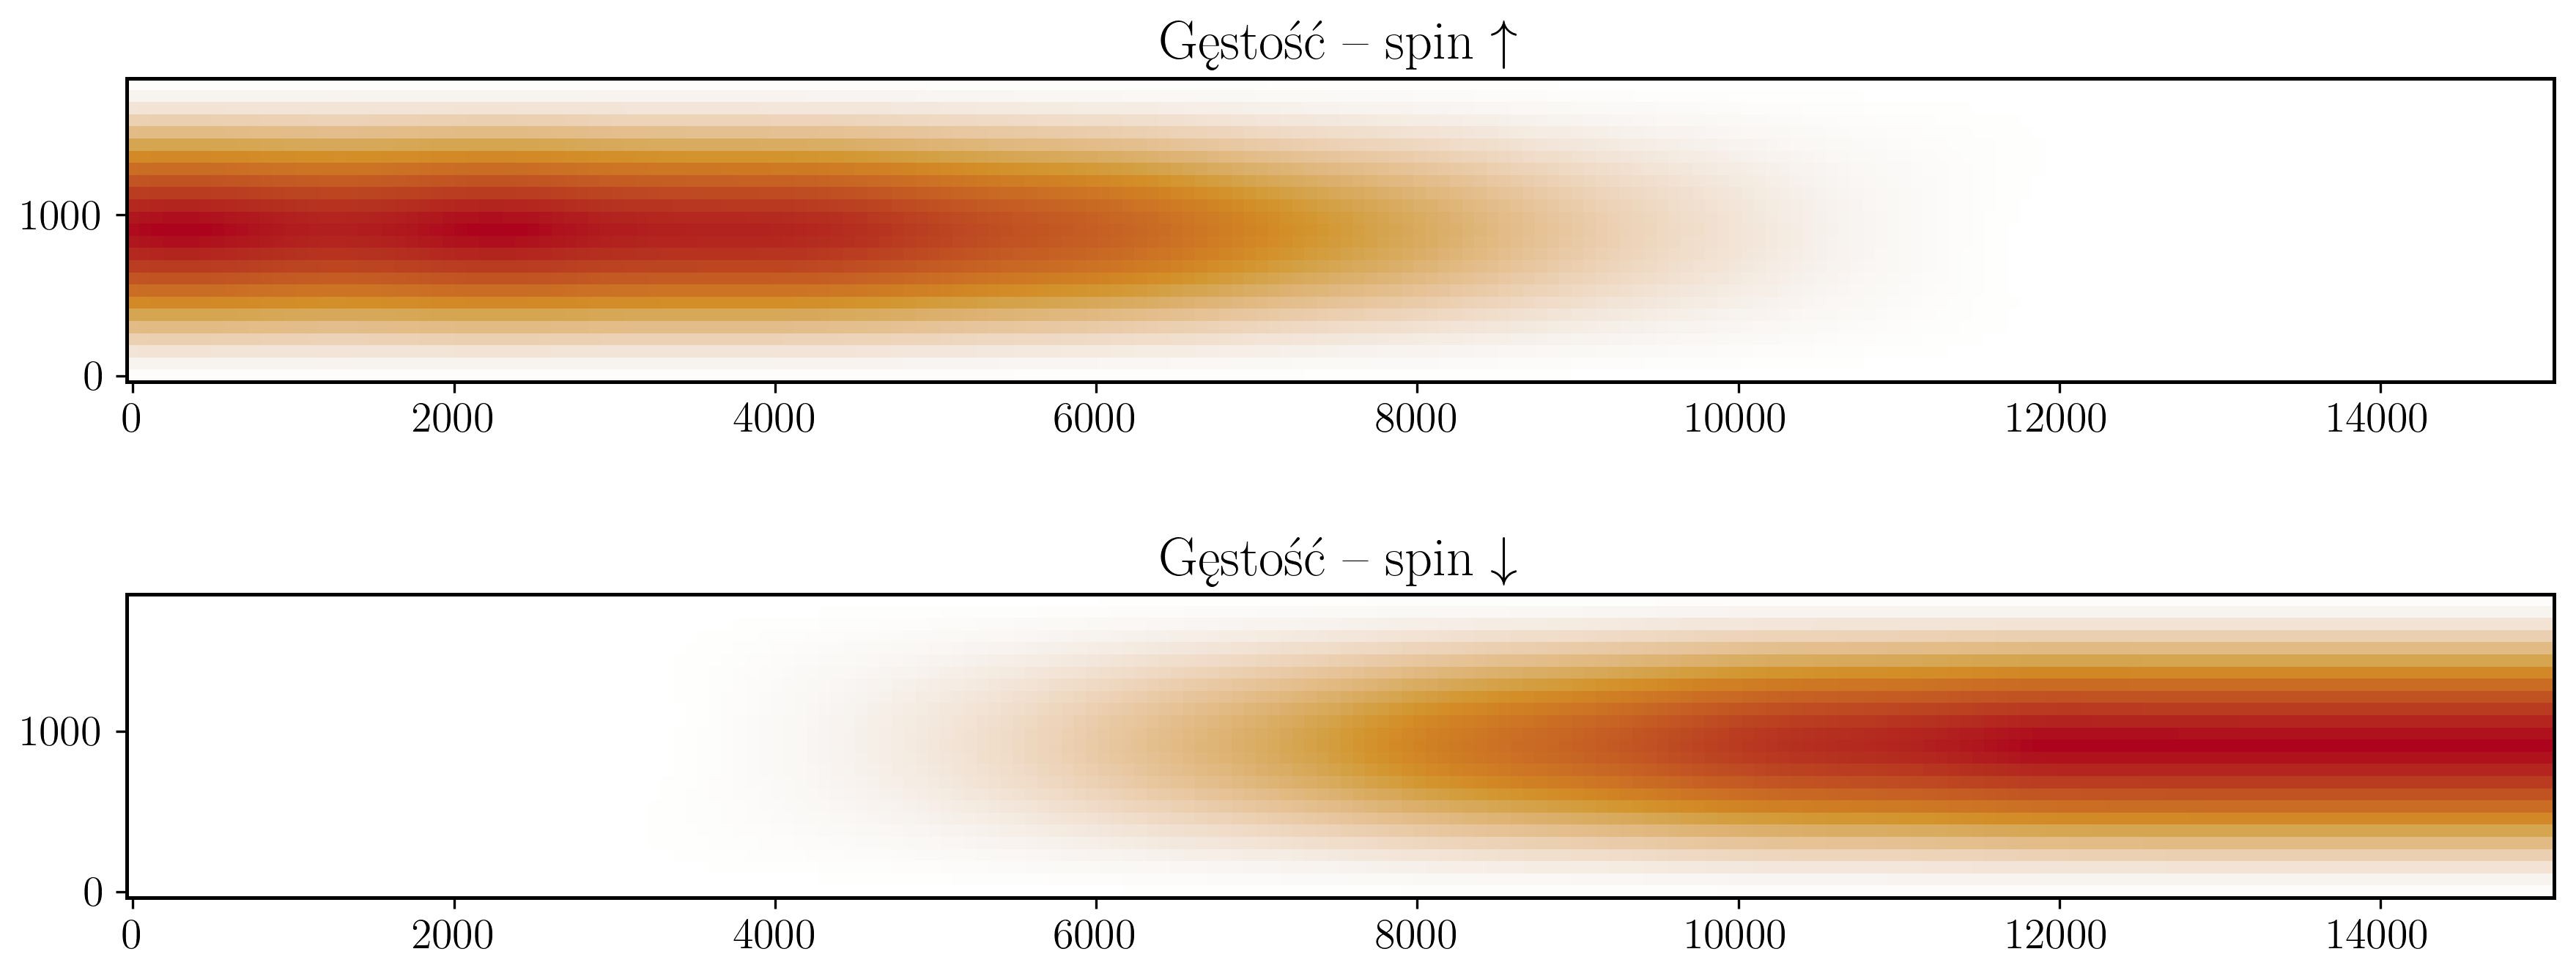

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
kwant.plotter.map(sys, rho_up, ax=ax1)
ax1.set_title(r"Gęstość – spin $\uparrow$")
kwant.plotter.map(sys, rho_down, ax=ax2)
ax2.set_title(r"Gęstość – spin $\downarrow$")
plt.tight_layout()
plt.savefig("zad_3/eden_updown.png", dpi=150)
plt.show()

In [36]:
sx_op = kwant.operator.Density(sys, sx)
sy_op = kwant.operator.Density(sys, sy)
sz_op = kwant.operator.Density(sys, sz)
 
sx_map = sx_op(wf[0])
sy_map = sy_op(wf[0])
sz_map = sz_op(wf[0])

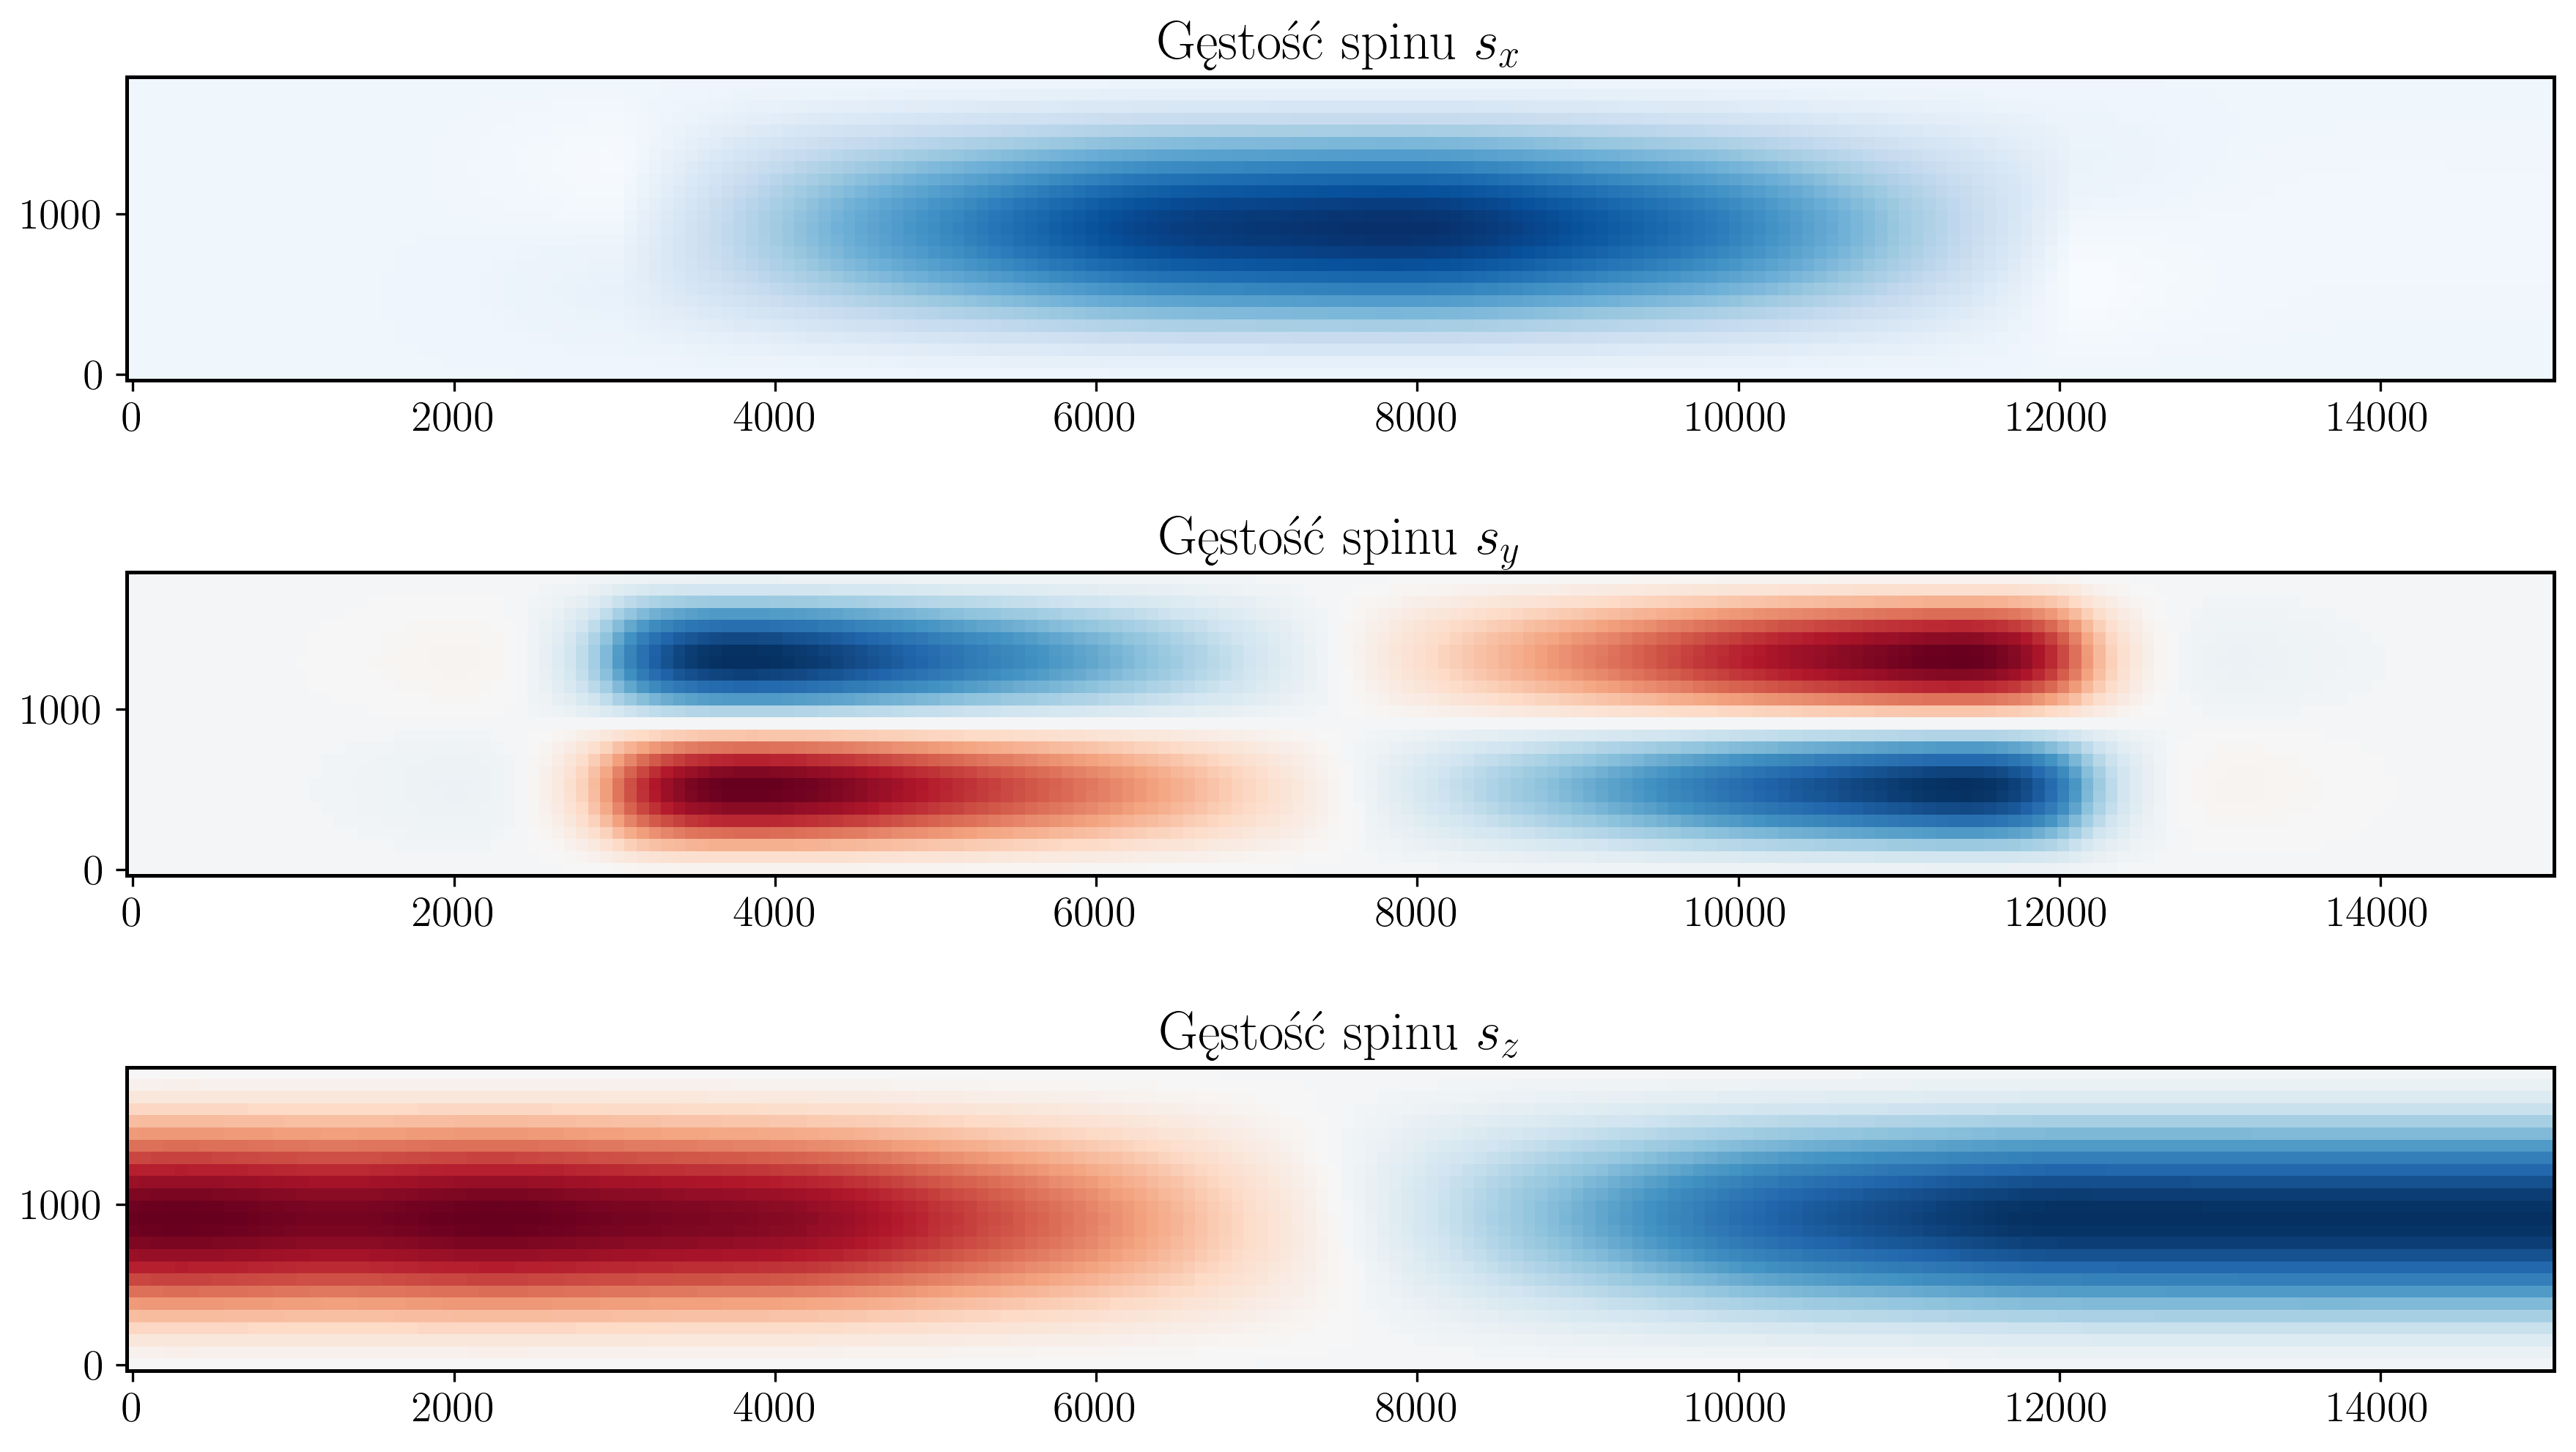

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7))
kwant.plotter.map(sys, sx_map, cmap="Blues_r", ax=ax1)
ax1.set_title(r"Gęstość spinu $s_x$")
kwant.plotter.map(sys, sy_map, cmap="RdBu_r", ax=ax2)
ax2.set_title(r"Gęstość spinu $s_y$")
kwant.plotter.map(sys, sz_map, cmap="RdBu_r", ax=ax3)
ax3.set_title(r"Gęstość spinu $s_z$")
plt.tight_layout()
plt.savefig("zad_3/sden_xyz.png", dpi=150)
plt.show()